In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/soumyaranjansundaray/hotel-booking-dataset-analysis/hotel_bookings.csv


# About Hotel Booking Dataset

The hospitality industry experiences significant challenges due to booking cancellations, fluctuating customer demand, seasonal trends, and varying booking behaviors. Understanding these patterns enables hotel management to optimize occupancy, improve revenue, reduce cancellation losses, and enhance customer satisfaction.

This project performs an Exploratory Data Analysis (EDA) on hotel booking data to identify customer booking patterns, analyze cancellation behavior, understand seasonal demand, and discover the key factors influencing hotel reservations. The analysis also provides actionable business insights that can help hotels improve operational efficiency and customer retention.

# Goal of The Project

- The primary objective of this project is to analyze hotel booking data to understand customer behavior and identify the major factors affecting hotel reservations and cancellations.

- The analysis aims to answer several important business questions, including:

    - Which hotel type receives the highest number of bookings?
    - What factors contribute to booking cancellations?
    - Which months experience peak booking demand?
    - How do booking lead times affect cancellation rates?
    - Which countries contribute the highest number of guests?
    - What customer segments generate the most bookings?
    - Which market segments and distribution channels drive hotel revenue?
    - How do adults, children, and babies influence booking patterns?
    - Which meal plans are most commonly selected?
    - What booking channels produce the highest cancellation rates?
    - How does the average length of stay vary between City Hotels and Resort Hotels?

- The ultimate goal is to generate business recommendations that help hotel management improve occupancy rates, reduce cancellations, optimize pricing strategies, and enhance customer experience.

# Dataset Used
The dataset contains hotel booking information collected from both City Hotels and Resort Hotels over multiple years. Each record represents a single hotel reservation and includes information related to customer demographics, booking details, reservation status, stay duration, and hotel characteristics.

The dataset is widely used for data analytics, business intelligence, and machine learning projects focused on customer behavior and hotel demand forecasting.

# Data Gathering

In [2]:
link = '/kaggle/input/datasets/soumyaranjansundaray/hotel-booking-dataset-analysis/hotel_bookings.csv'

In [3]:
pd.set_option('display.max_columns',None)
df = pd.read_csv(link)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# import data visualisation libraries 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
# importing additional libraries 
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Data Assessment

In [5]:
# basic assessing techniques 

# shape 
df.shape


(119390, 32)

The Dataset Contains total 119390 rows of data in 32 Columns.

In [6]:
#Seeking Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

- The Dataset contains 20 Numerical (4 float and 16 Int) and 12 Object Datatypes
- The dataset has 4 columns with missing values. Those columns are children , country , agent and company.
- Company column has 6797 booking , which is ~6% of total bookings.
- Missing value for very less i.e. 4. This is negligible and can be ed from dataset.
- Country information is almost complete and can be reliably used for geographic and customer segmentation analyses. The missing value can be removed as it's small in number.
- While many bookings were made through travel agents, a considerable number were booked directly or have missing agent information. Appropriate imputation or categorization should be considered before analysis.
- Numerical Columns : is_canceled, lead_time, arrival_date_year, arrival_date_week_number, arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, booking_changes, agent, company, days_in_waiting_list, adr (Average Daily Rate), required_car_parking_spaces, and total_of_special_requests
- Categorical columns : hotel, arrival_date_month, meal, country, market_segment, distribution_channel,  reserved_room_type, assigned_room_type, deposit_type, customer_type, reservation_status, reservation_status_date

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
# numerical columns 

# seeking description 
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


From the description, below summary is derived:
- The descriptive statistics reveal several important characteristics of the hotel booking dataset. On average, approximately 37% of all bookings were canceled, indicating a relatively high cancellation rate that can significantly affect hotel occupancy and revenue.

- Customers booked their stays 104 days in advance on average, although lead times varied considerably from 0 to 737 days, suggesting that some reservations were made nearly two years before arrival.

- Most bookings occurred during 2016 and 2017, with arrivals distributed fairly evenly throughout the weeks and days of the year.

- Guests typically stayed for 1 weekend night and 2–3 weekday nights, indicating that short stays are the most common booking pattern.

- The majority of reservations were made for two adults, while bookings including children or babies were relatively uncommon, suggesting that most customers were couples or individual travelers rather than large families.

- Only 3.2% of guests were repeat customers, implying that the hotel primarily serves new visitors rather than returning guests.

- Previous booking cancellations and previous successful bookings were generally low for most customers, indicating that repeat booking behavior is relatively limited.

- Booking modifications were infrequent, with most reservations remaining unchanged after being made.

- The Average Daily Rate (ADR) was approximately 101.83, although the wide range (from -6.38 to 5400) indicates the presence of potential outliers or unusual pricing records that should be investigated during data cleaning.

- Very few guests requested car parking spaces, while the majority made zero or one special request, suggesting that additional customer requirements are generally minimal.

- The days on the waiting list variable has a median value of 0, indicating that most reservations were confirmed immediately without requiring customers to wait.

- Overall, the descriptive statistics show that the dataset is dominated by short-stay bookings from first-time guests traveling in small groups, with considerable variation in booking lead times and room prices. Additionally, several numerical variables, particularly ADR, lead time, stay duration, and waiting list days, exhibit large ranges and potential outliers, making them important candidates for further visualization using box plots and distribution analysis.

In [9]:
#Column Names
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

# Data Overview

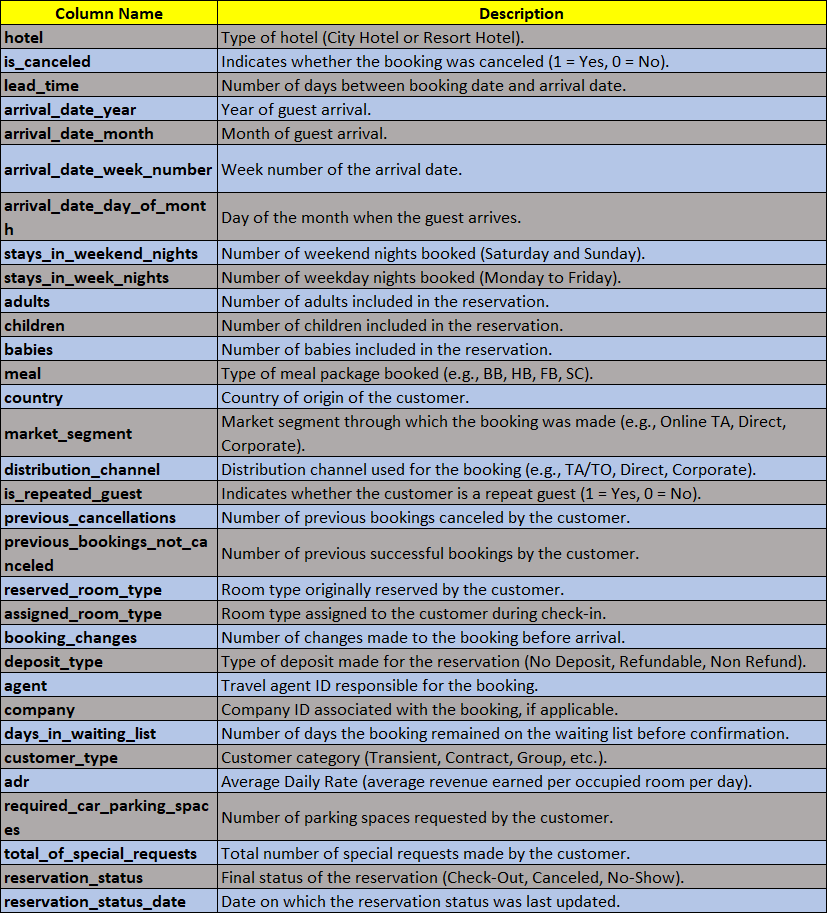

**Target Variable:**
- is_canceled
    - Yes (1) --> Booking was cancelled
    - No (0) --> Booking was not cancelled

# Data Preprocessing

In [10]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Missing Value Analysis

In [11]:
# verify missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

The Dataset contains 4 columns which has Missing values. 
- Children has 4 missing values, so these 4 rows can be removed from the dataset
- Country has 488 null values, so this can be removed from the dataset
- Company booking has very less data in the dataset. Hence this can be removed from the dataset for a better dataset.
- Agent has 16K + null records. Hence assigning 0 to the non-agent bookings for EDA check.

In [12]:
# remove rows for Country column as they have very less records presence

df = df.dropna(subset=['country'])


In [13]:
#Assigning Null to 0 for Children column to remove null records. Assuming No children

df['children']= df['children'].fillna(0)

#taking 0 value , in replace for Null values.

In [14]:
#Assigning Null to 0 for agent column to remove null records. For better EDA
df['agent']= df['agent'].fillna(0)

#taking 0 value , in replace for Null values.

In [15]:
#Assigning Null to 0 for company column to remove null records. For better EDA
df.drop(columns=['company'], inplace=True)

#taking 0 value , in replace for Null values.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118902 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118902 non-null  object 
 1   is_canceled                     118902 non-null  int64  
 2   lead_time                       118902 non-null  int64  
 3   arrival_date_year               118902 non-null  int64  
 4   arrival_date_month              118902 non-null  object 
 5   arrival_date_week_number        118902 non-null  int64  
 6   arrival_date_day_of_month       118902 non-null  int64  
 7   stays_in_weekend_nights         118902 non-null  int64  
 8   stays_in_week_nights            118902 non-null  int64  
 9   adults                          118902 non-null  int64  
 10  children                        118902 non-null  float64
 11  babies                          118902 non-null  int64  
 12  meal                 

- After removing the Null values for country, drop Company Column and replace null value with 0 for other columns, Remaing Rows remain as 118902 with 32 columns.
- The dataset is not complete and can be used for EDA.

# Data Duplicacy Check

In [17]:
# check duplicate data in the dataset
df.duplicated().sum()

np.int64(31965)

Total 31965 rows are found to be duplicate rows.

In [18]:
# duplicate columns

df.T.duplicated().sum()

np.int64(0)

None of the columns are found to be duplicated.

In [19]:
#checking Duplicacy Percetage for further analysis
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate %:", round((duplicate_count/len(df))*100,2), "%")

Duplicate rows: 31965
Duplicate %: 26.88 %


The Dataset contains ~27 % duplicate data, so this can be dropped for better EDA performance of the Dataset.

In [20]:
#dropping all the duplicate rows from the dataset
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)
print(df.duplicated().sum())

(86937, 31)
0


After dropping the rows and columns, the remaining Rows are 86937 and columns are 31.

# Data Integrity & Inconsistency Sanity Audit

In [21]:
#Create New Column for Total Guests
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

In [22]:
#check Ghost Guests
ghost_guests = df[df["total_guests"] == 0]

In [23]:
#Count the invalid records
ghost_count = len(ghost_guests)

print("Total Ghost Guest Records:", ghost_count)

Total Ghost Guest Records: 161


In [24]:
#Percentage of invalid records
ghost_percentage = (ghost_count / len(df)) * 100

print(f"Ghost Guest Percentage: {ghost_percentage:.2f}%")

Ghost Guest Percentage: 0.19%


In [25]:
#Ghost Guest details
ghost_guests.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
2087,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06,0.0
2223,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-10-12,0.0
2803,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23,0.0
3090,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04,0.0
3098,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05,0.0


**Key Insights**

Only a small percentage of bookings contain zero guests, suggesting isolated data entry errors or logging inconsistencies. These observations should be investigated or removed prior to analysis to ensure data integrity.

In [26]:
#Remvoing the Ghost records from the dataset
print("Before:", len(df))

df = df[df["total_guests"] != 0]

print("After:", len(df))

Before: 86937
After: 86776


- As Ghost Records are not useful for EDA, so we removed the fields for the same.
- After removal of Ghost Guests, 86776 records are still present.

**Financial Anomaly Extraction**

Objective

Find bookings that:

- were not canceled
- have ADR ≤ 0

These may represent:

- Complimentary stays
- Employee bookings
- Accounting errors
- Incorrect data entries

In [27]:
#Find Financial Anomalies

financial_anomalies = df[
    (df["is_canceled"] == 0) &
    (df["adr"] <= 0)
]

print("Financial Anomalies:", len(financial_anomalies))

Financial Anomalies: 1464


In [28]:
#Find Anomalies Percentage
percentage = (
    len(financial_anomalies)
    / len(df)
) * 100

print(f"Percentage: {percentage:.2f}%")

Percentage: 1.69%


In [29]:
financial_anomalies.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
121,Resort Hotel,0,32,2015,July,27,4,0,1,4,0.0,0,FB,PRT,Complementary,Direct,0,0,0,H,H,2,No Deposit,0.0,0,Transient,0.0,0,1,Check-Out,2015-07-05,4.0
162,Resort Hotel,0,111,2015,July,28,6,0,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,H,0,No Deposit,240.0,0,Transient,0.0,0,2,Check-Out,2015-07-06,2.0
163,Resort Hotel,0,0,2015,July,28,6,0,0,1,0.0,0,BB,PRT,Direct,Direct,0,0,0,E,H,0,No Deposit,250.0,0,Transient,0.0,0,0,Check-Out,2015-07-06,1.0


**Key Insights**

 - Completed bookings with zero or negative Average Daily Rate (ADR) may represent complimentary stays, promotional bookings, internal employee accommodations, or accounting inconsistencies. These observations should be validated before conducting revenue analysis.
 - These record will not show true nature of Hotel Booking/Cancaellation pattern as most of them are either promotional/Complimentary booking/Internal Employee, which doesn't hold much monetary benefits or error in bookings. hence we should remove the data for better EDA performance.

In [30]:
#Remove the Financial Anomalies for better EDA

print("Before:", len(df))

df = df[~((df["is_canceled"] == 0) & (df["adr"] <= 0))]

print("After:", len(df))

print(len(df[(df["is_canceled"] == 0) & (df["adr"] <= 0)]))

Before: 86776
After: 85312
0


After removing the anomaly data, remaining records are 85312.

**Temporal Feature Aggregation**

In [31]:
# Create a new column by merging 3 columns to get better time series analysis

df["datetime"] = pd.to_datetime(
    df["arrival_date_year"].astype(str)
    + "-"
    + df["arrival_date_month"]
    + "-"
    + df["arrival_date_day_of_month"].astype(str)
)

In [32]:
#showing the columns

df[[
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "datetime"
]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,datetime
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01
5,2015,July,1,2015-07-01
6,2015,July,1,2015-07-01


In [33]:
# verify the datatype
df["datetime"].dtype

dtype('<M8[ns]')

In [34]:
#verify Month wise how many times a single month is present in Dataset

df.groupby(df["datetime"].dt.month).size()

datetime
1      4529
2      5919
3      7325
4      7762
5      8210
6      7647
7      9879
8     11086
9      6529
10     6709
11     4813
12     4904
dtype: int64

In [35]:
#verify Year wise how many times a single Year is present in Dataset

df.groupby(df["datetime"].dt.year).size()

datetime
2015    12752
2016    41342
2017    31218
dtype: int64

<Axes: xlabel='datetime'>

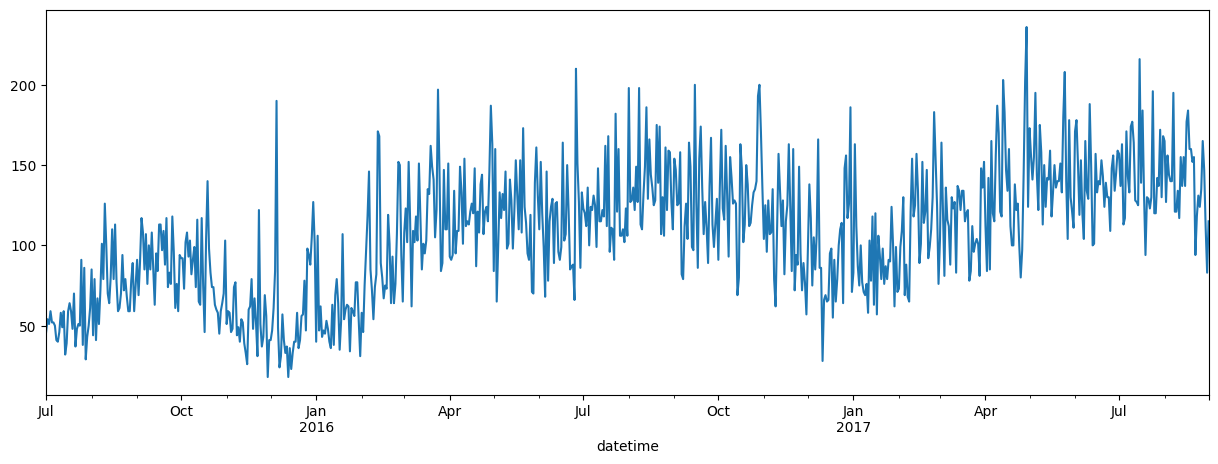

In [36]:
#Plot to check distribution over time 

bookings = df.groupby("datetime").size()

bookings.plot(figsize=(15,5))

Above plot represents below data:
1. Bookings increased in every year
2. Mostly, There is a dip in hotel bookings during Oct-Jan period.
3. The dip increases again from January End or February.
4. Guests during pick period remains between 100 to 200. Whereas average remains around 150.

# Exploratory Data Analysis

In [37]:
from scipy.stats import skew, kurtosis

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [38]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object','<M8[ns]']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_guests'],
      dtype='object')

Categorical Columns:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date', 'datetime'],
      dtype='object')


KDE Plot


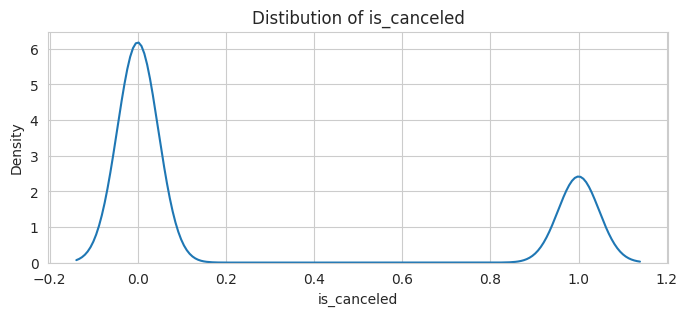

Histogram Plot


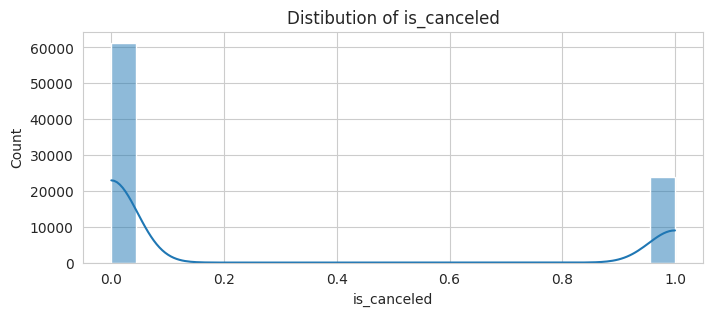

Whisker Plot


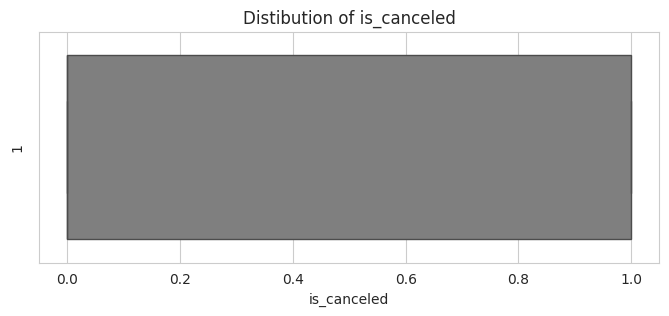

Violin Plot


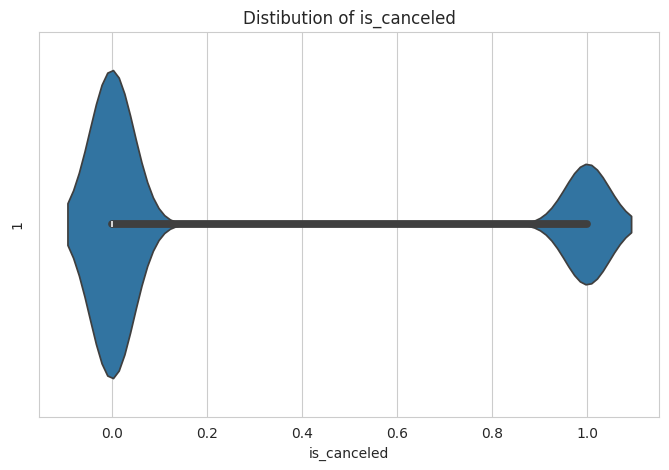

Skewness 	: 0.97
Kurtosis 	: -1.05
Mean   : 0.28
Median : 0.0
Mode   : 0
is_canceled is moderately right-skewed.
The distribution shows very little to no presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


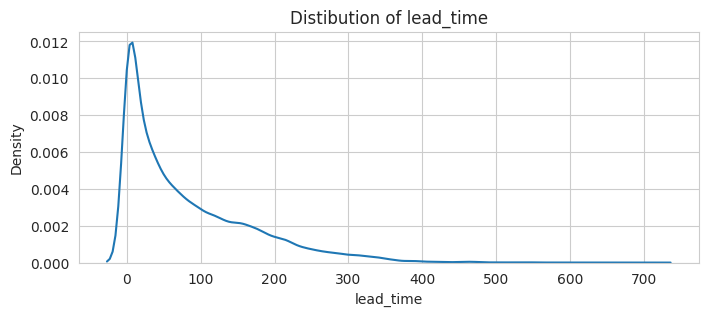

Histogram Plot


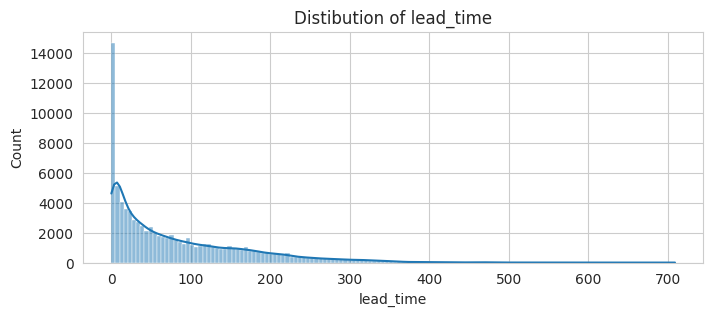

Whisker Plot


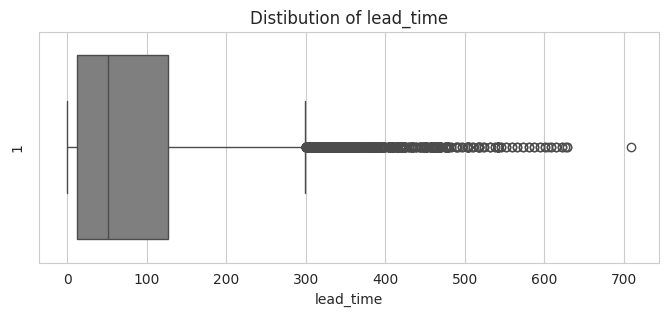

Violin Plot


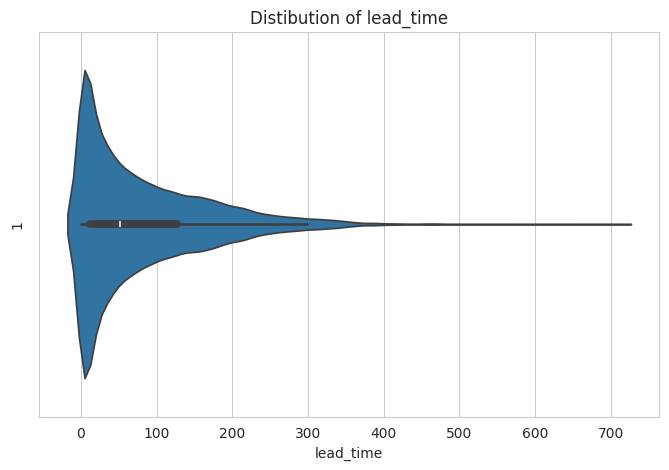

Skewness 	: 1.41
Kurtosis 	: 2.03
Mean   : 81.0
Median : 51.0
Mode   : 0
lead_time is highly right-skewed.
The distribution suggests a moderate presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


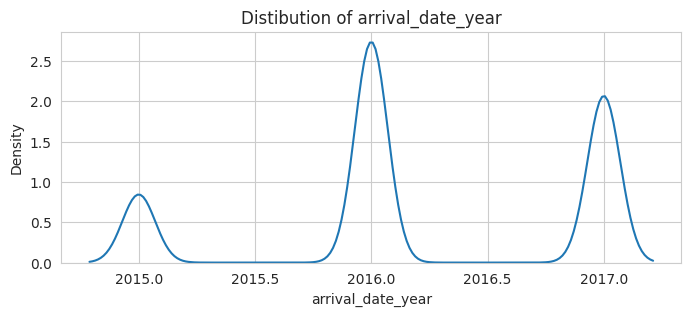

Histogram Plot


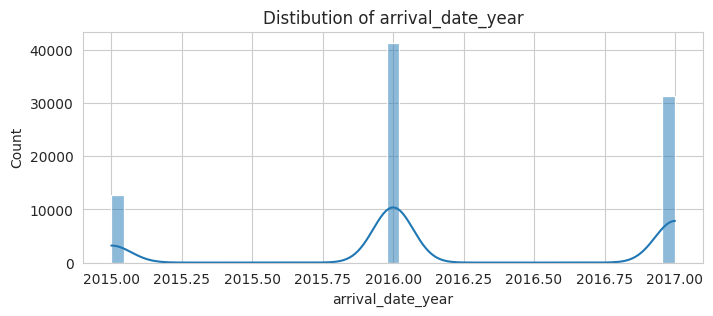

Whisker Plot


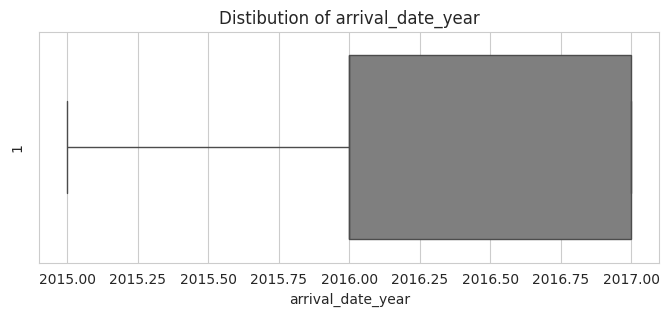

Violin Plot


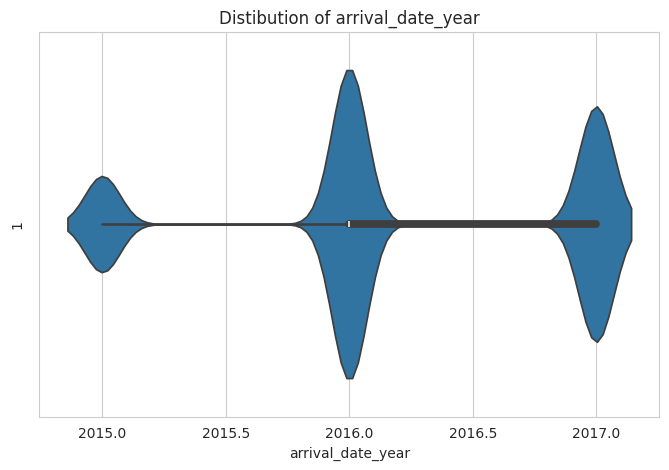

Skewness 	: -0.31
Kurtosis 	: -0.88
Mean   : 2016.22
Median : 2016.0
Mode   : 2016
arrival_date_year is approximately normally distributed.
The distribution contains few outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


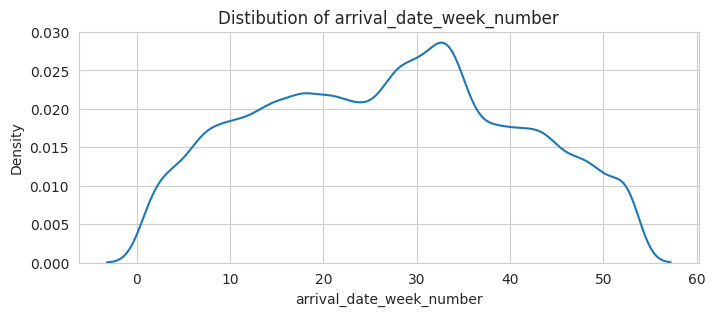

Histogram Plot


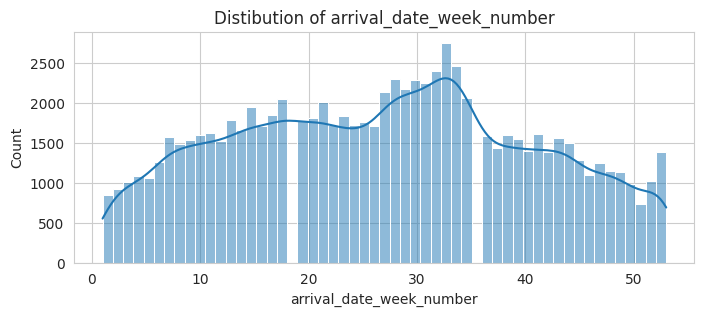

Whisker Plot


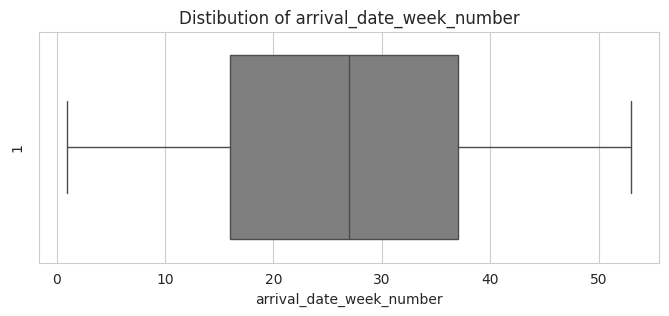

Violin Plot


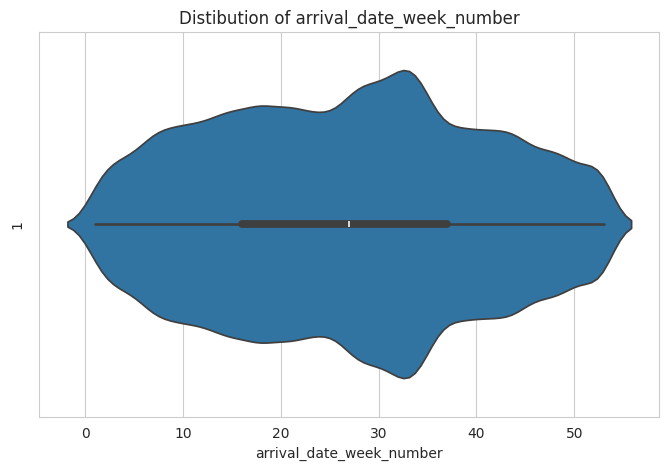

Skewness 	: 0.02
Kurtosis 	: -0.94
Mean   : 26.8
Median : 27.0
Mode   : 33
arrival_date_week_number is approximately normally distributed.
The distribution contains few outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


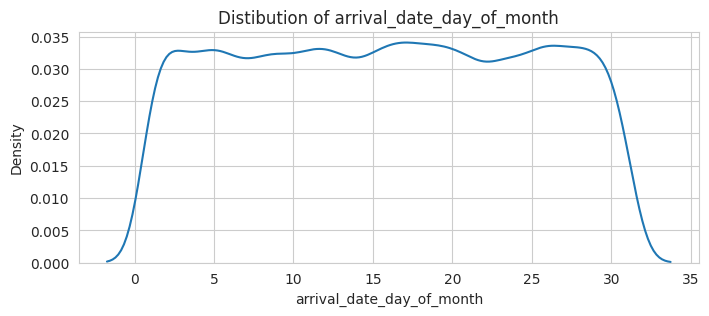

Histogram Plot


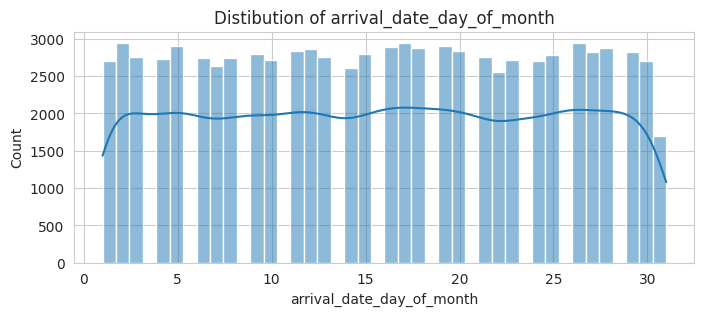

Whisker Plot


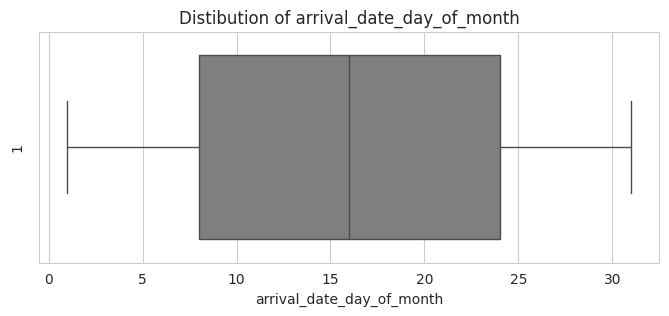

Violin Plot


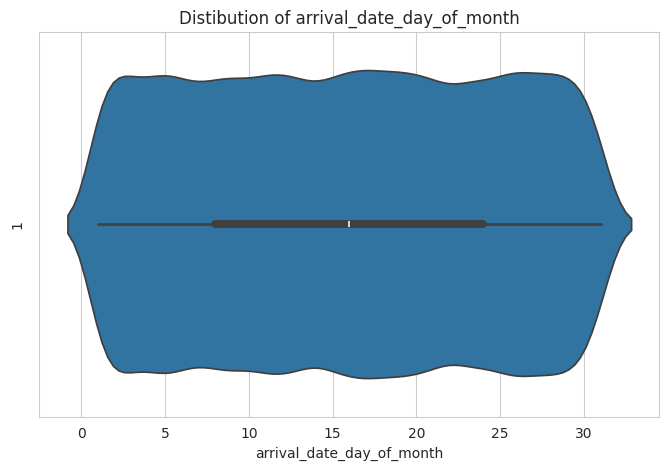

Skewness 	: -0.0
Kurtosis 	: -1.2
Mean   : 15.83
Median : 16.0
Mode   : 17
arrival_date_day_of_month is approximately normally distributed.
The distribution shows very little to no presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


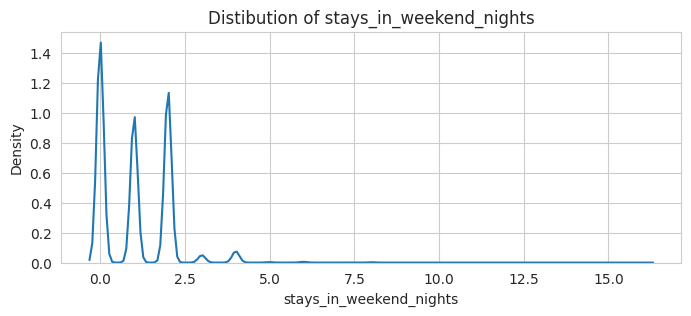

Histogram Plot


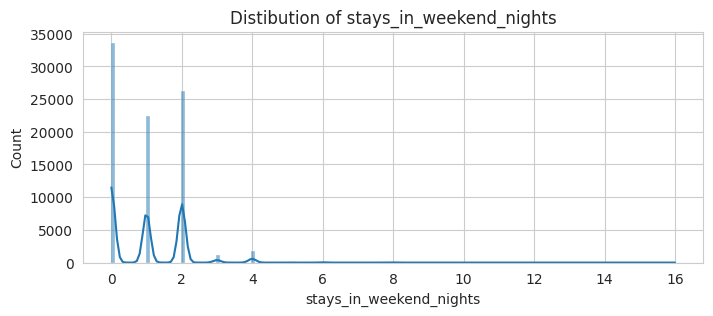

Whisker Plot


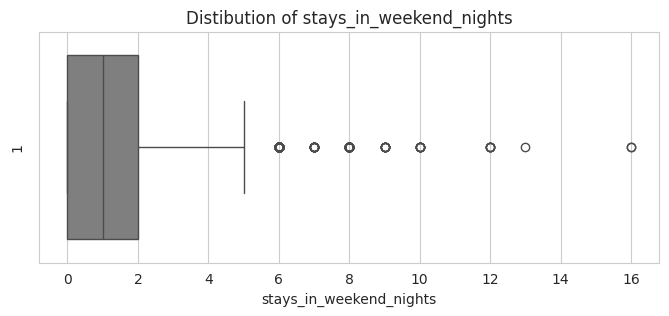

Violin Plot


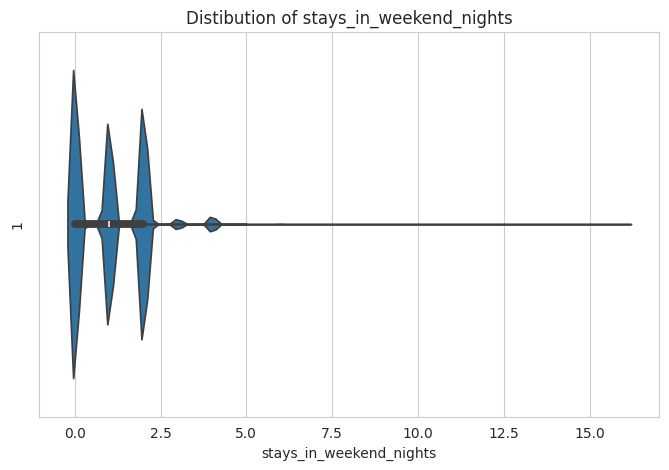

Skewness 	: 1.19
Kurtosis 	: 4.78
Mean   : 1.02
Median : 1.0
Mode   : 0
stays_in_weekend_nights is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


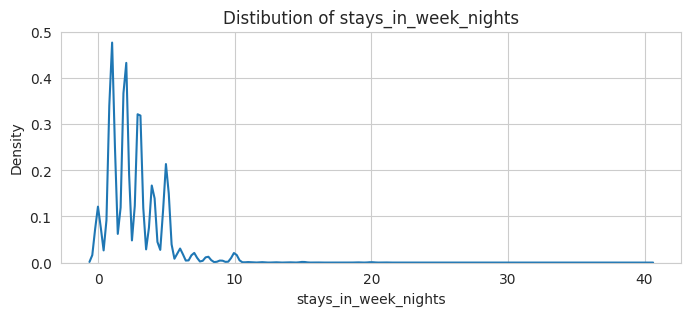

Histogram Plot


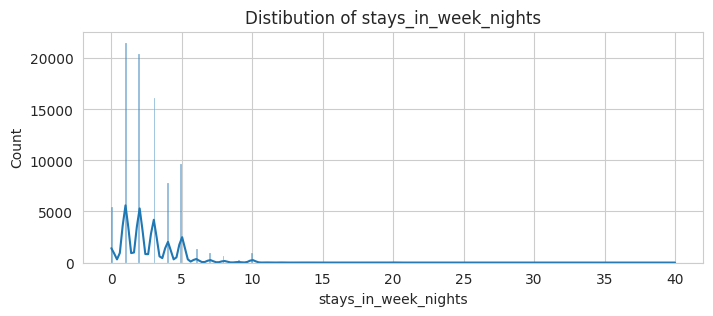

Whisker Plot


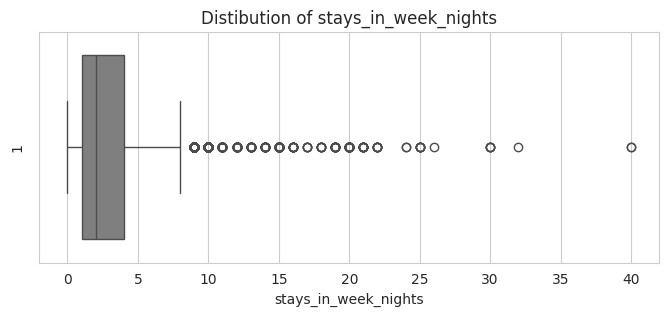

Violin Plot


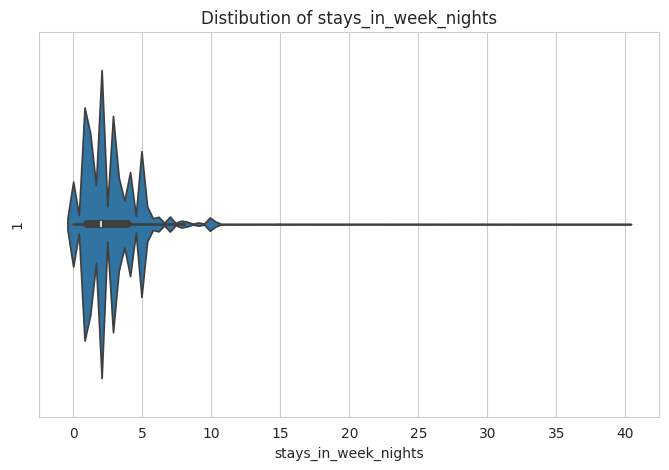

Skewness 	: 2.34
Kurtosis 	: 14.65
Mean   : 2.65
Median : 2.0
Mode   : 1
stays_in_week_nights is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


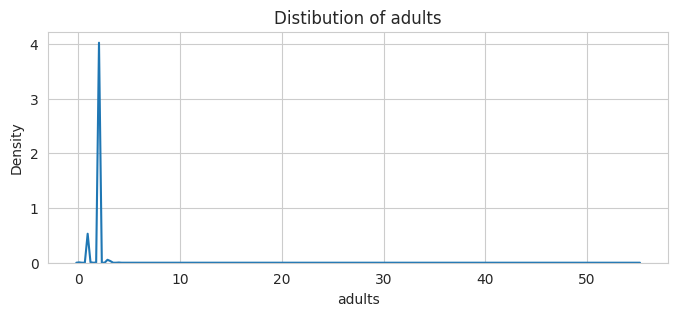

Histogram Plot


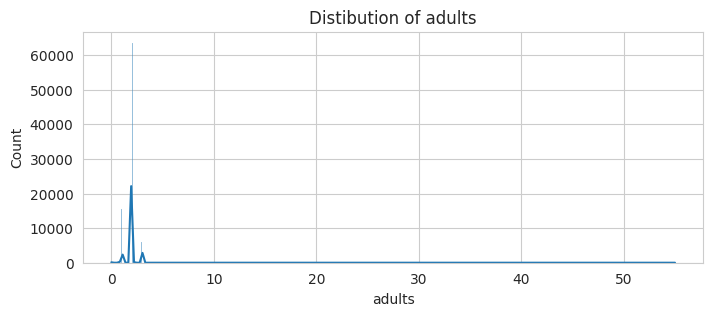

Whisker Plot


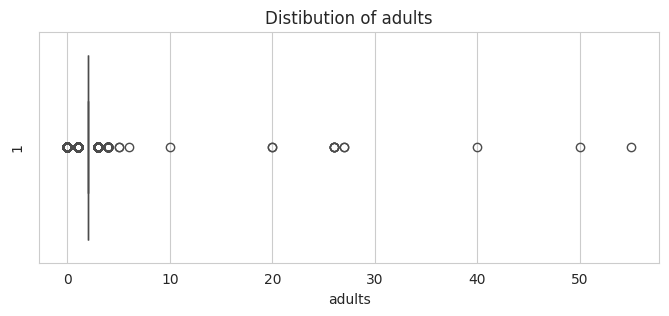

Violin Plot


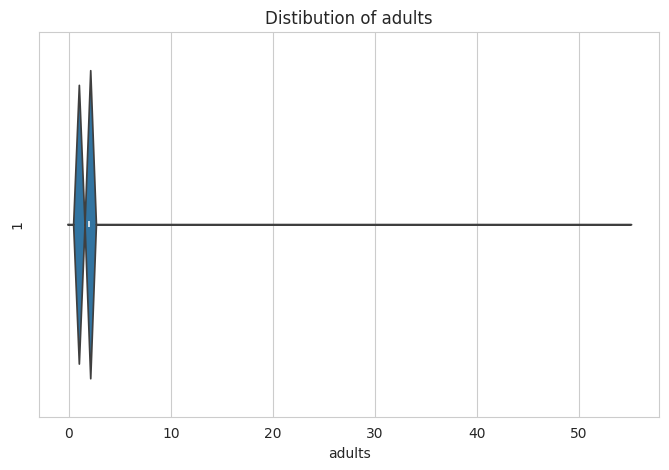

Skewness 	: 20.92
Kurtosis 	: 1428.5
Mean   : 1.89
Median : 2.0
Mode   : 2
adults is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


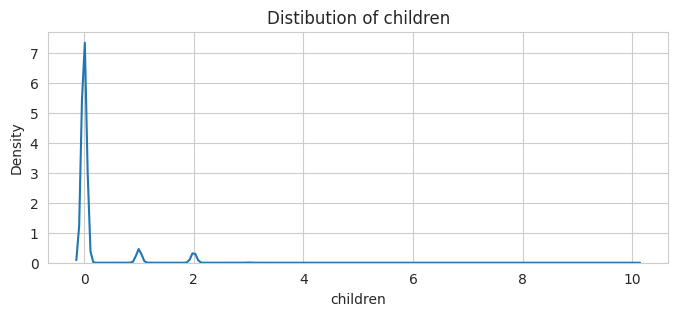

Histogram Plot


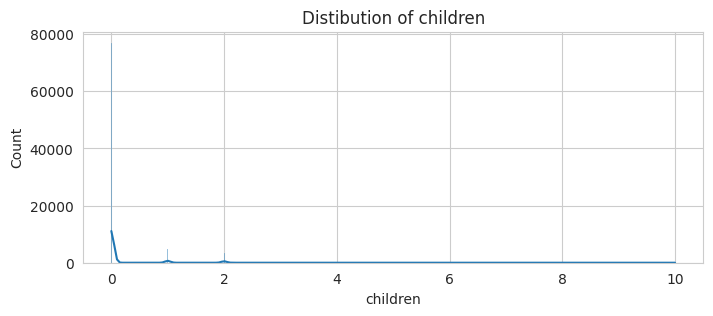

Whisker Plot


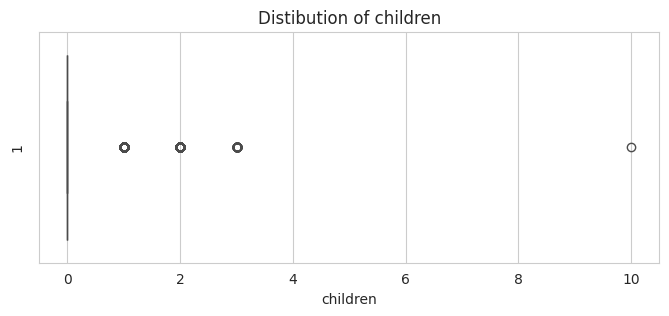

Violin Plot


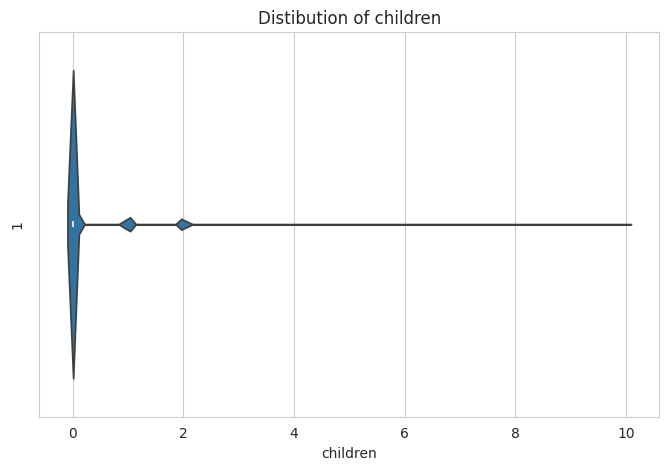

Skewness 	: 3.44
Kurtosis 	: 12.75
Mean   : 0.14
Median : 0.0
Mode   : 0.0
children is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


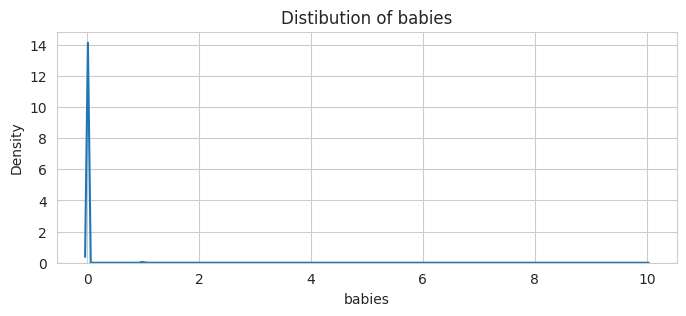

Histogram Plot


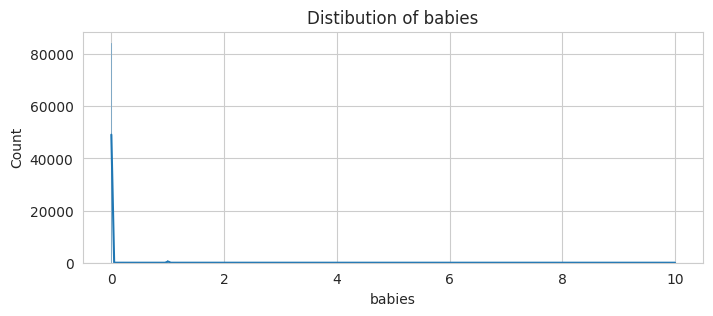

Whisker Plot


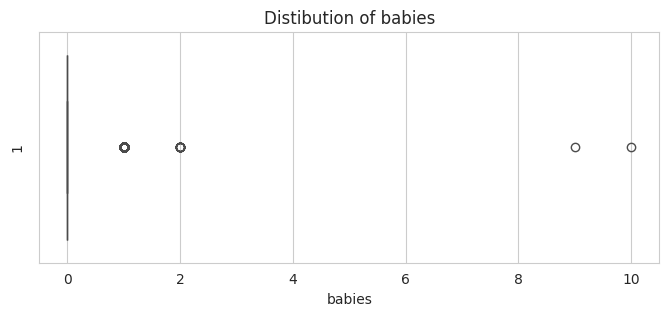

Violin Plot


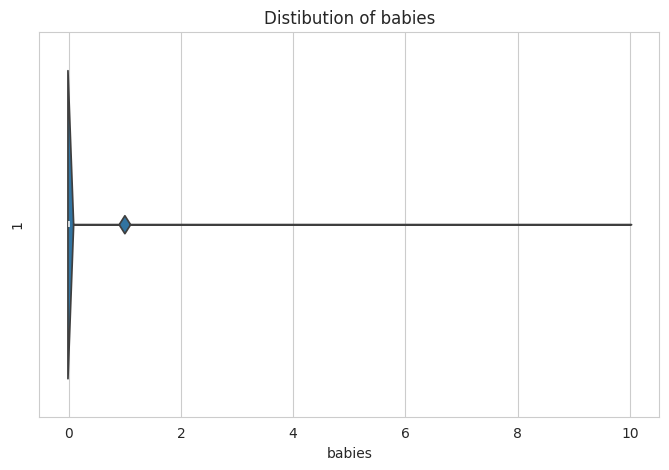

Skewness 	: 21.46
Kurtosis 	: 1235.83
Mean   : 0.01
Median : 0.0
Mode   : 0
babies is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


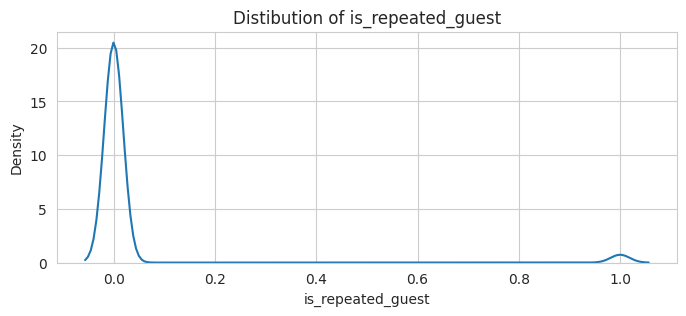

Histogram Plot


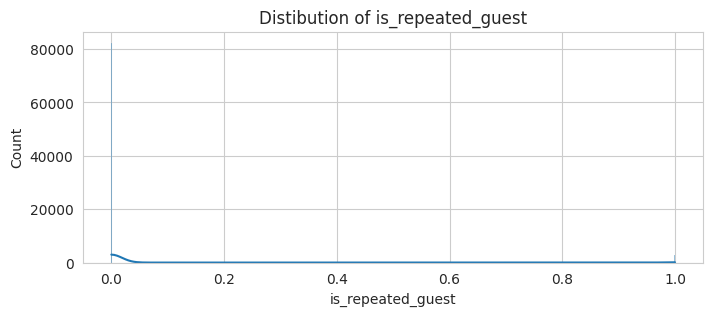

Whisker Plot


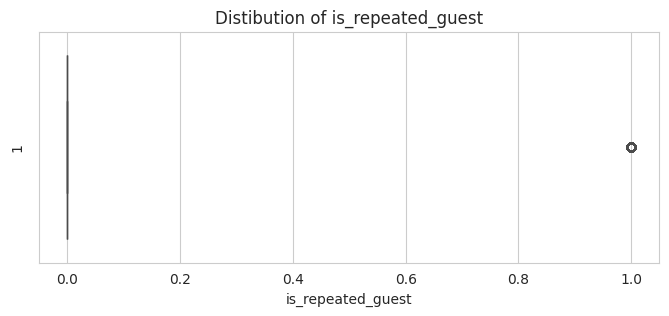

Violin Plot


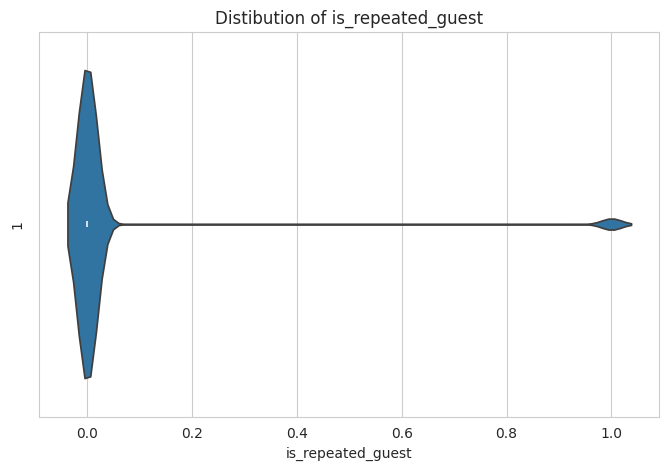

Skewness 	: 5.11
Kurtosis 	: 24.08
Mean   : 0.03
Median : 0.0
Mode   : 0
is_repeated_guest is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


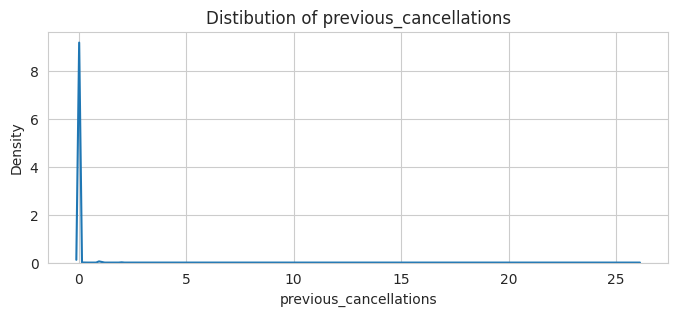

Histogram Plot


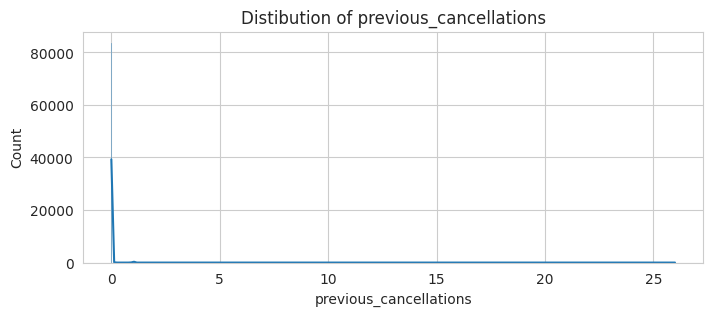

Whisker Plot


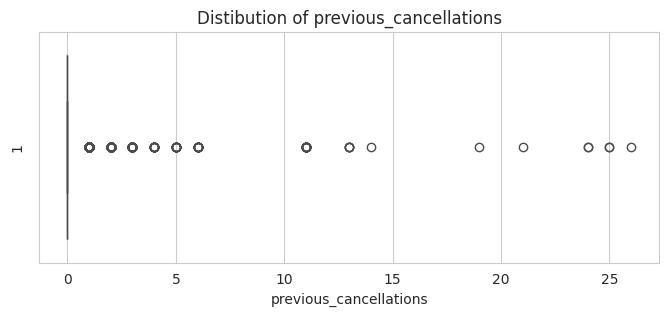

Violin Plot


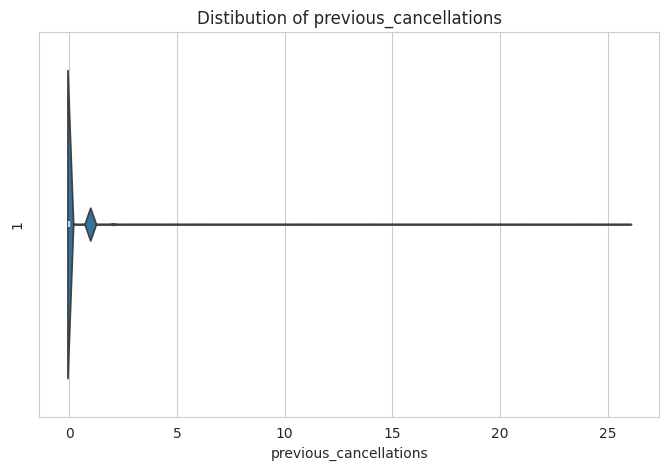

Skewness 	: 35.7
Kurtosis 	: 1827.41
Mean   : 0.03
Median : 0.0
Mode   : 0
previous_cancellations is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


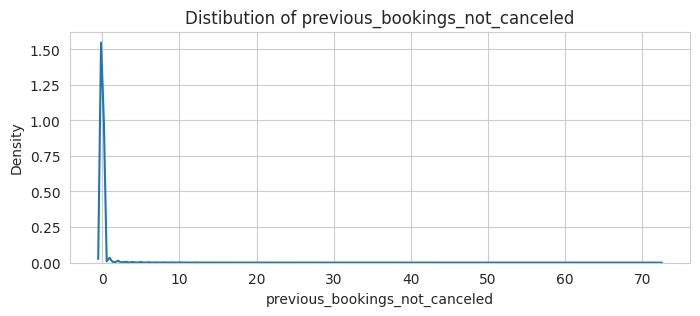

Histogram Plot


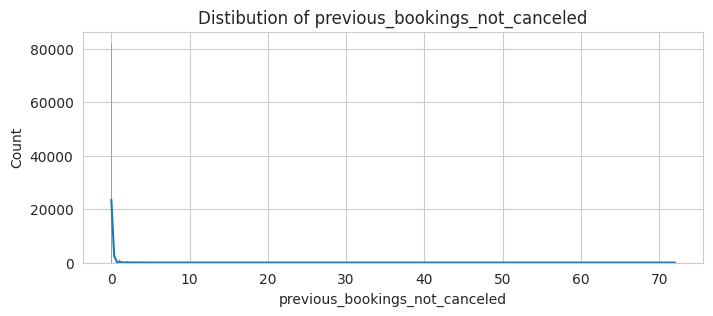

Whisker Plot


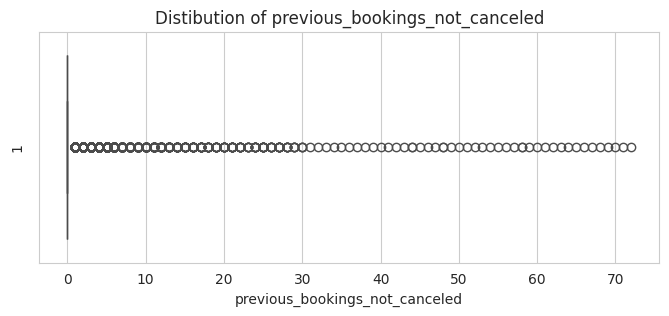

Violin Plot


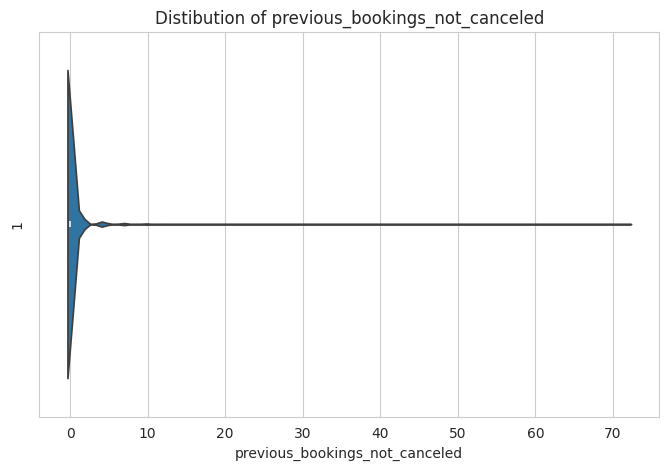

Skewness 	: 22.51
Kurtosis 	: 685.06
Mean   : 0.16
Median : 0.0
Mode   : 0
previous_bookings_not_canceled is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


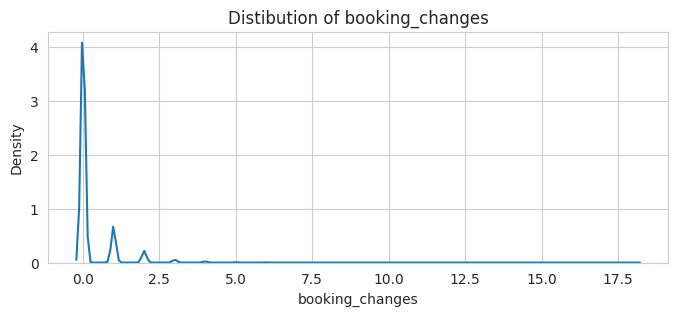

Histogram Plot


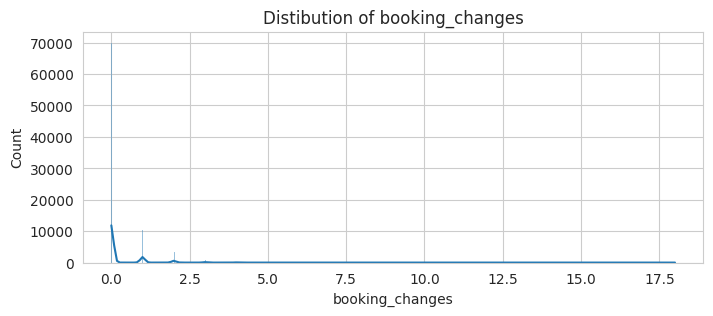

Whisker Plot


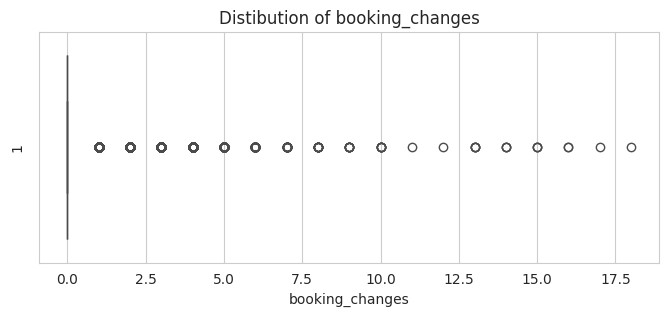

Violin Plot


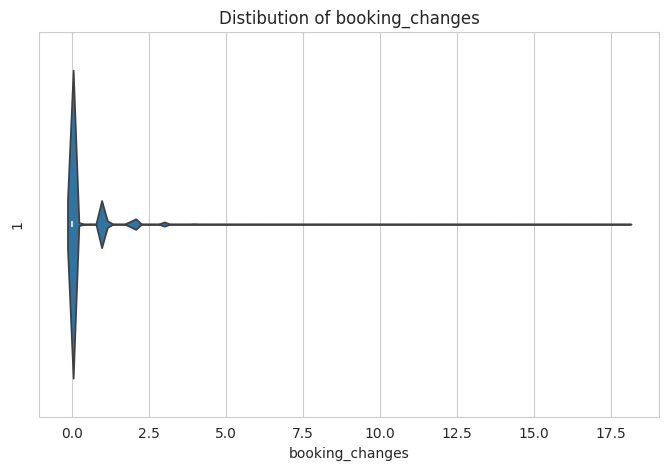

Skewness 	: 4.96
Kurtosis 	: 51.55
Mean   : 0.27
Median : 0.0
Mode   : 0
booking_changes is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


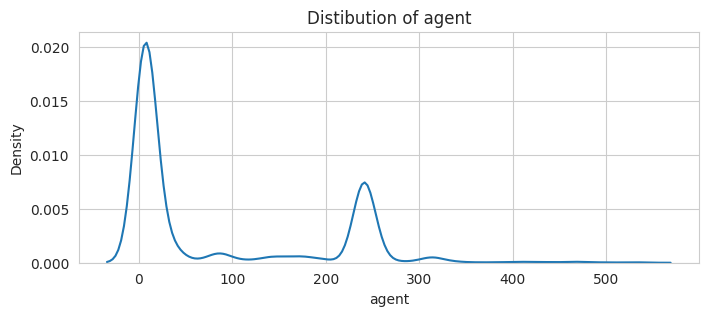

Histogram Plot


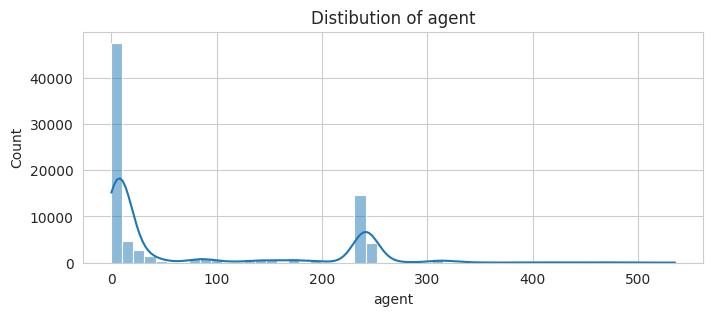

Whisker Plot


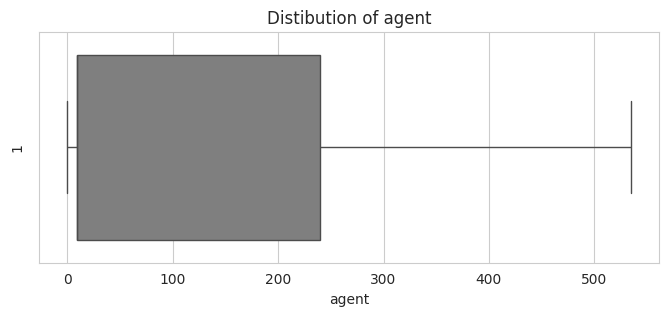

Violin Plot


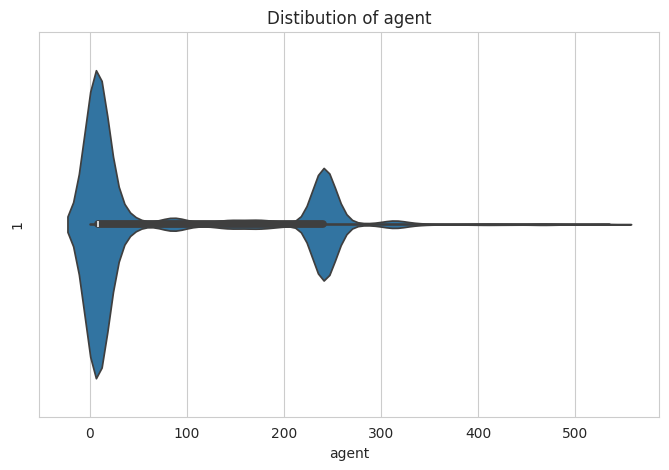

Skewness 	: 1.1
Kurtosis 	: -0.09
Mean   : 81.54
Median : 9.0
Mode   : 9.0
agent is highly right-skewed.
The distribution contains few outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


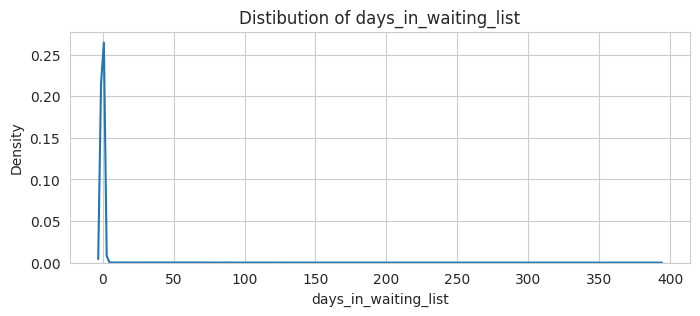

Histogram Plot


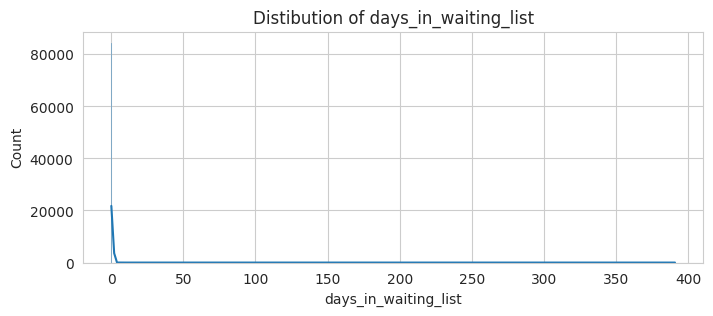

Whisker Plot


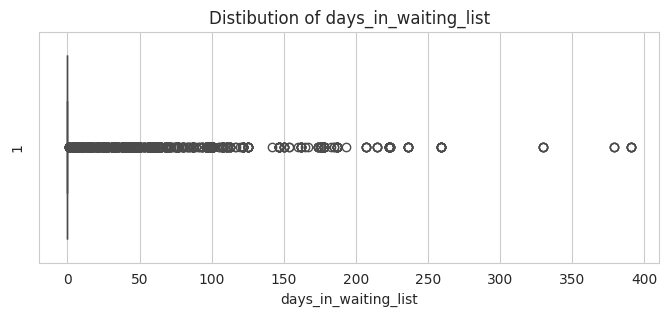

Violin Plot


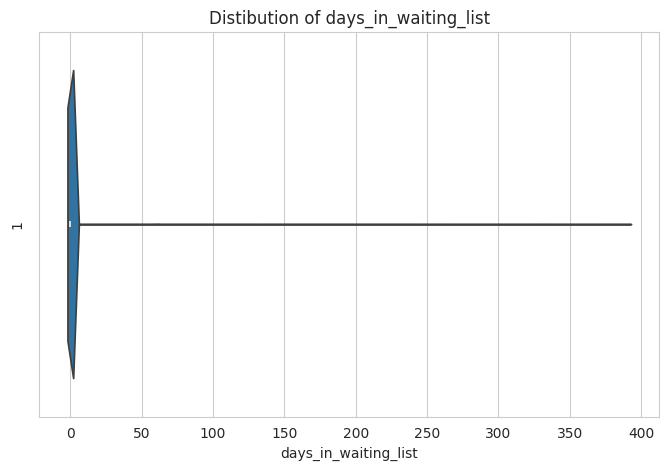

Skewness 	: 19.56
Kurtosis 	: 487.36
Mean   : 0.75
Median : 0.0
Mode   : 0
days_in_waiting_list is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


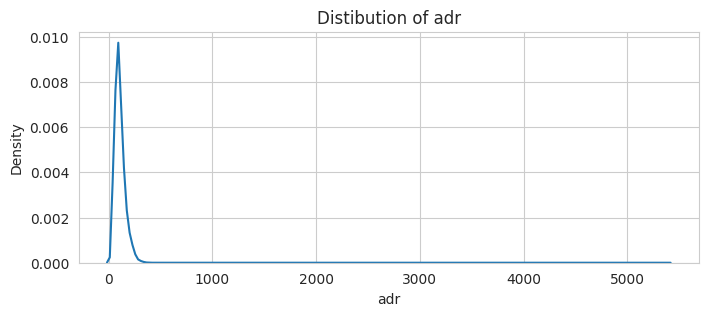

Histogram Plot


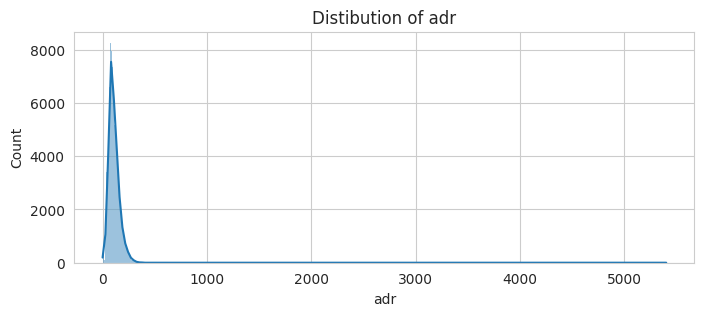

Whisker Plot


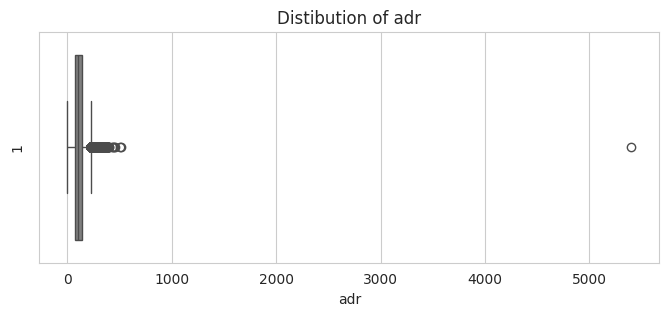

Violin Plot


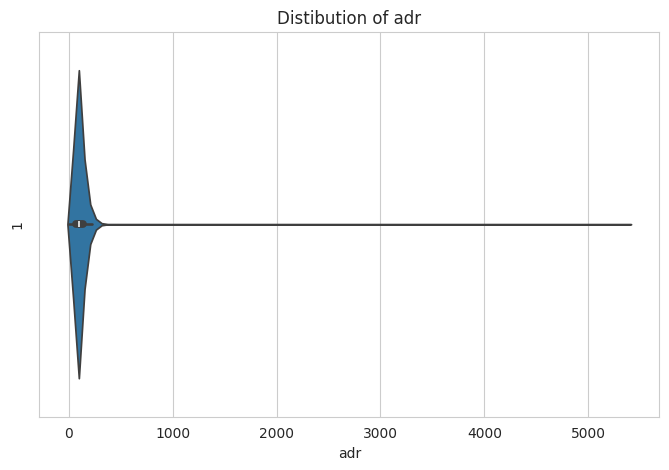

Skewness 	: 12.21
Kurtosis 	: 1124.27
Mean   : 108.58
Median : 99.0
Mode   : 75.0
adr is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


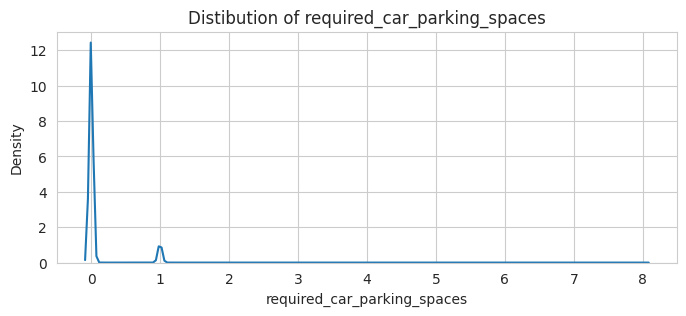

Histogram Plot


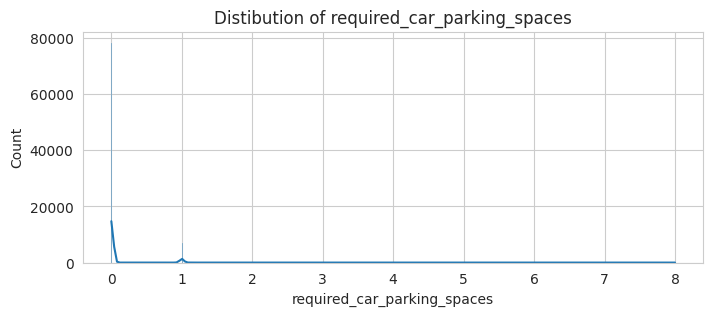

Whisker Plot


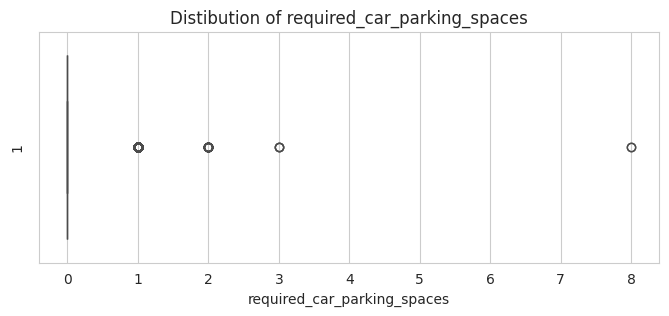

Violin Plot


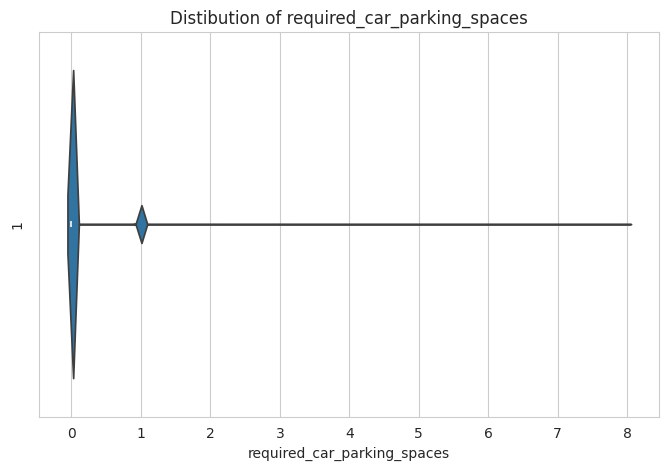

Skewness 	: 3.52
Kurtosis 	: 22.26
Mean   : 0.08
Median : 0.0
Mode   : 0
required_car_parking_spaces is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


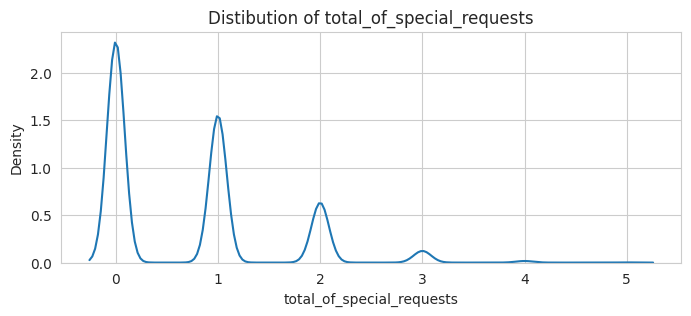

Histogram Plot


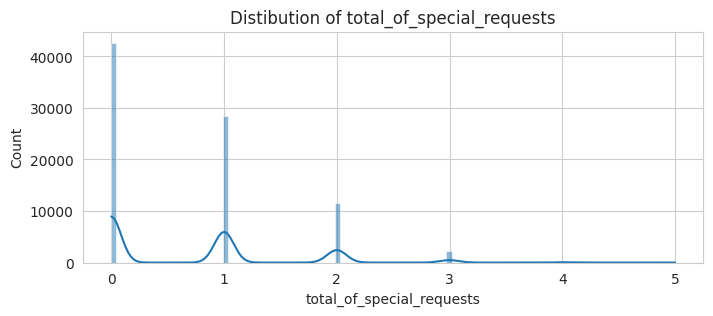

Whisker Plot


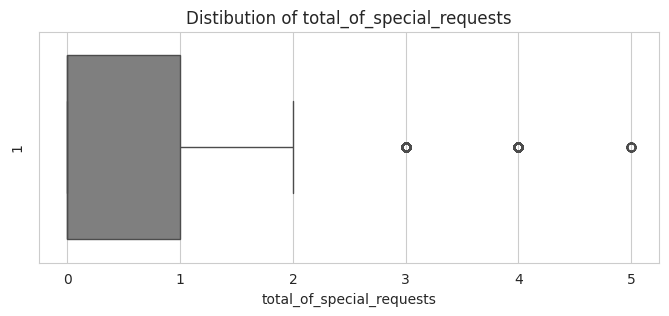

Violin Plot


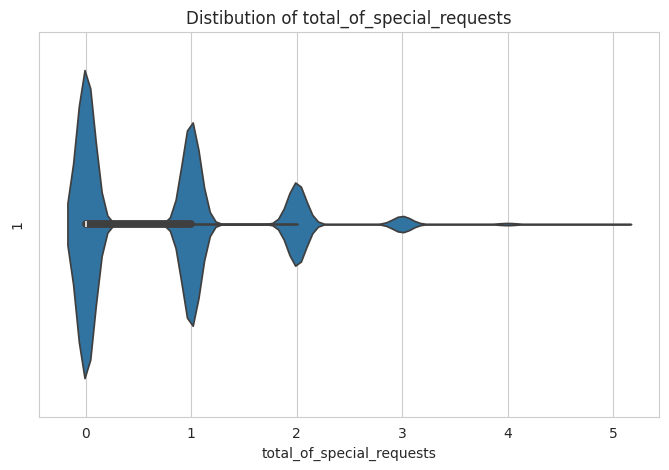

Skewness 	: 1.07
Kurtosis 	: 0.79
Mean   : 0.7
Median : 0.0
Mode   : 0
total_of_special_requests is highly right-skewed.
The distribution suggests a moderate presence of outliers.
----------------------------------------------------------------------------------------------------
KDE Plot


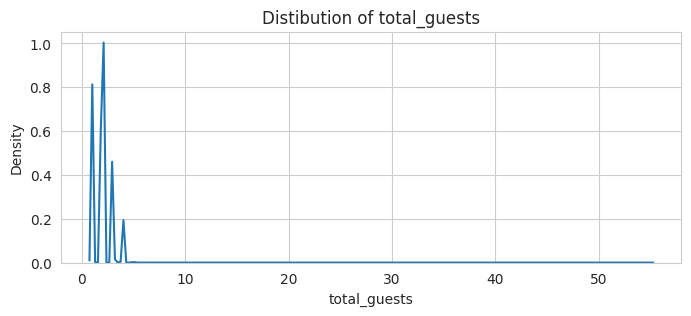

Histogram Plot


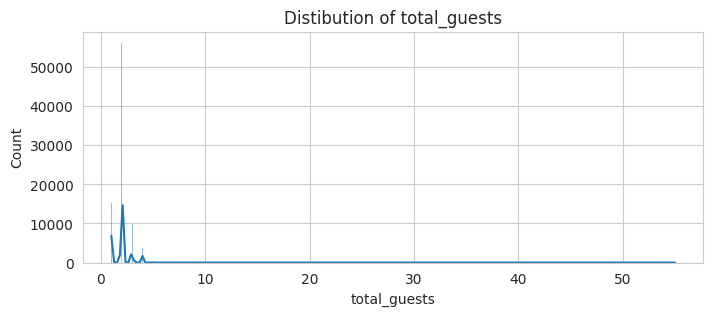

Whisker Plot


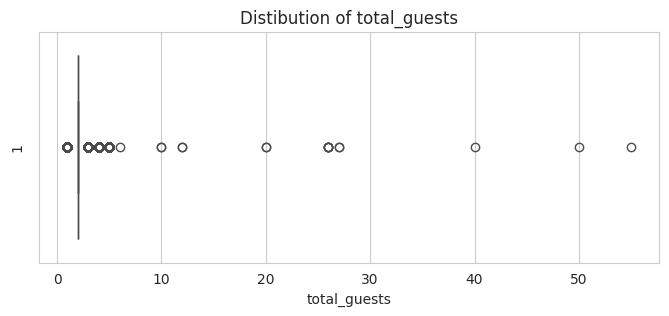

Violin Plot


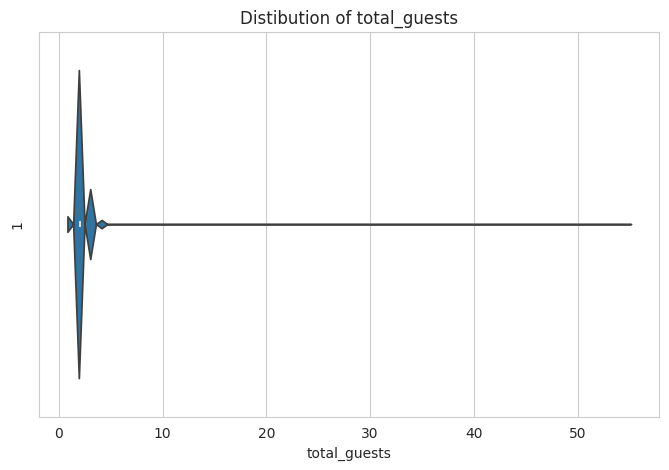

Skewness 	: 10.78
Kurtosis 	: 539.78
Mean   : 2.04
Median : 2.0
Mode   : 2.0
total_guests is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------


In [39]:
#Univariate Analysis on Numerical Columns
for i in numerical_cols:
    print("KDE Plot")
    plt.figure(figsize=(8,3))
    sns.kdeplot(df[i])
    plt.title(f'Distibution of {i}')
    plt.show()
    print("Histogram Plot")
    plt.figure(figsize=(8,3))
    sns.histplot(df[i],kde=True,palette='grey_r')
    plt.title(f'Distibution of {i}')
    plt.show()
    print('Whisker Plot')
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[i],palette='grey_r')
    plt.title(f'Distibution of {i}')
    plt.ylabel(1)
    plt.show()
    print('Violin Plot')
    plt.figure(figsize=(8,5))
    sns.violinplot(x=df[i])
    plt.title(f'Distibution of {i}')
    plt.ylabel(1)
    plt.show()
    skew = df[i].skew()
    kurt = df[i].kurtosis()
    print('Skewness \t:',round(skew,2))
    print('Kurtosis \t:',round(kurt,2))
    # Skewness Interpretation

    print("Mean   :", round(df[i].mean(), 2))
    print("Median :", round(df[i].median(), 2))
    print("Mode   :", round(df[i].mode()[0], 2))
    
    if skew > 1:
        print(f"{i} is highly right-skewed.")
    elif skew > 0.5:
        print(f"{i} is moderately right-skewed.")
    elif skew < -1:
        print(f"{i} is highly left-skewed.")
    elif skew < -0.5:
        print(f"{i} is moderately left-skewed.")
    else:
        print(f"{i} is approximately normally distributed.")

    # Kurtosis Interpretation
    if kurt > 3:
        print(f"The distribution indicates a high presence of outliers.")
    elif kurt > 0:
        print(f"The distribution suggests a moderate presence of outliers.")
    elif kurt > -1:
        print(f"The distribution contains few outliers.")
    else:
        print(f"The distribution shows very little to no presence of outliers.")

    print("-" * 100)

**Key Insights**
1. Booking Cancellations

Approximately 28% of bookings were canceled, while the majority were successfully completed. The is_canceled variable is moderately right-skewed, indicating that successful bookings significantly outnumber cancellations.

2. Booking Lead Time

Customers book their stays an average of 81 days before arrival, although booking lead times vary considerably. The highly right-skewed distribution suggests that while most reservations are made within a few months of arrival, a smaller number are booked far in advance.

3. Arrival Dates

The arrival year, week number, and day of the month are all approximately normally distributed, indicating that bookings are well spread across the available time period without any strong concentration on specific dates.

4. Length of Stay

Most guests stay for 1 weekend night and 2 weekday nights, confirming that short-duration stays are the dominant booking pattern. However, a small number of guests book much longer stays, resulting in noticeable outliers.

5. Guest Composition

Most reservations are made for two adults, while bookings involving children or babies are relatively uncommon. The distributions of adults, children, and babies are highly right-skewed because larger family groups represent only a small proportion of bookings.

6. Repeat Customers

The vast majority of bookings come from first-time guests, with only a small percentage representing repeat visitors. This indicates that the hotels rely heavily on attracting new customers.

7. Previous Booking History

Most customers have no previous cancellations and no prior completed bookings, suggesting that repeat booking behavior is relatively limited. Only a few customers exhibit extensive booking histories, creating highly skewed distributions.

8. Booking Modifications

Most reservations are finalized without any booking changes. Only a small number of bookings undergo multiple modifications, producing a highly right-skewed distribution.

9. Travel Agents

Agent identifiers show highly skewed distributions because bookings are concentrated among a relatively small number of travel agents and companies.

10. Waiting List

Most bookings are confirmed immediately without spending time on a waiting list. Only a very small number of reservations experience extended waiting periods.

11. Average Daily Rate (ADR)

The Average Daily Rate (ADR) exhibits significant variability and contains several extreme values. The highly right-skewed distribution suggests that while most room rates fall within a typical pricing range, a few luxury or premium bookings substantially increase the maximum value.

12. Parking Requirements

Most guests do not request parking spaces. Only a small proportion require one or more parking spaces, resulting in a highly right-skewed distribution.

13. Special Requests

The majority of guests make zero or one special request, while only a few customers request multiple additional services. This indicates that special requests are generally limited across bookings.

14. Total Guests

Most hotel bookings are made for one or two guests, with larger groups being relatively rare. The highly right-skewed distribution reflects the occasional presence of group or family reservations.


**Major Insights**
The numerical features reveal that the hotel booking dataset is dominated by short stays, bookings for one or two adults, first-time customers, and reservations with minimal modifications or special requests. Most variables exhibit strong positive skewness, indicating that the majority of observations are concentrated at lower values, while a relatively small number of bookings contain exceptionally large values, resulting in numerous outliers. Variables such as lead time, ADR, length of stay, and waiting list days show substantial variability and warrant further investigation. 

Analysis of hotel
hotel
City Hotel      52412
Resort Hotel    32900
Name: count, dtype: int64


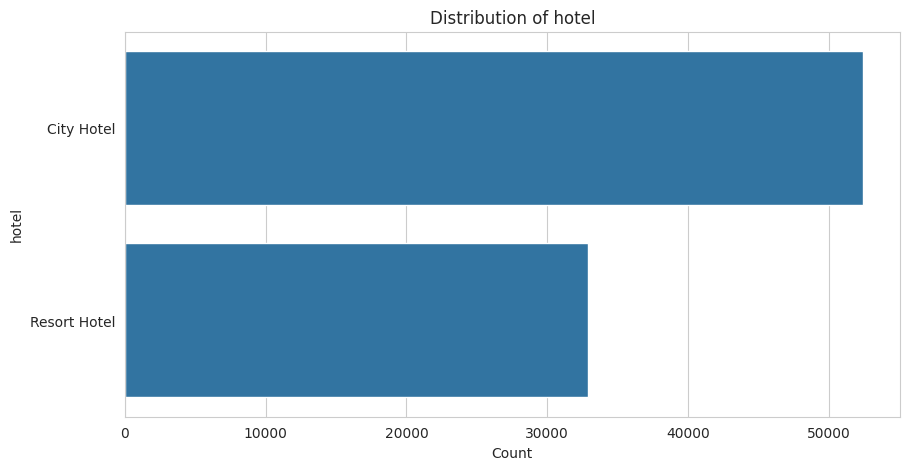


Unique Values : 2

Most Frequent Category :
City Hotel
--------------------------------------------------------------------------------
Analysis of arrival_date_month
arrival_date_month
August       11086
July          9879
May           8210
April         7762
June          7647
March         7325
October       6709
September     6529
February      5919
December      4904
November      4813
January       4529
Name: count, dtype: int64


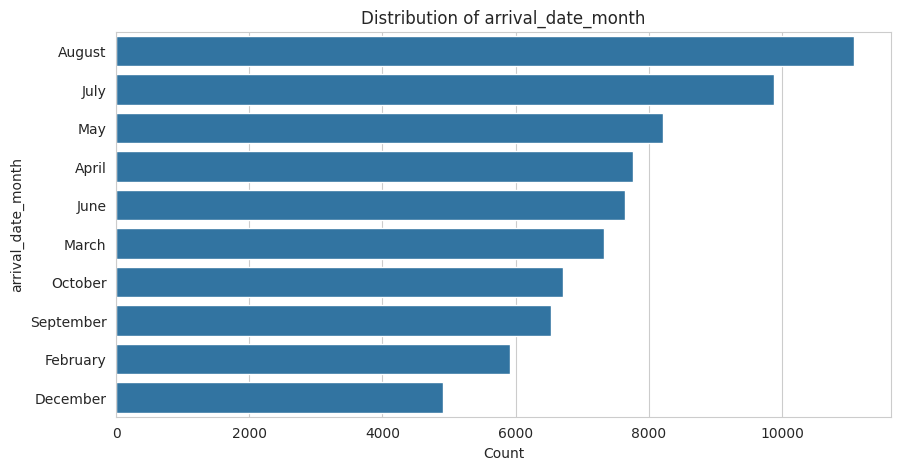


Unique Values : 12

Most Frequent Category :
August
--------------------------------------------------------------------------------
Analysis of meal
meal
BB           66314
SC            9270
HB            8922
Undefined      461
FB             345
Name: count, dtype: int64


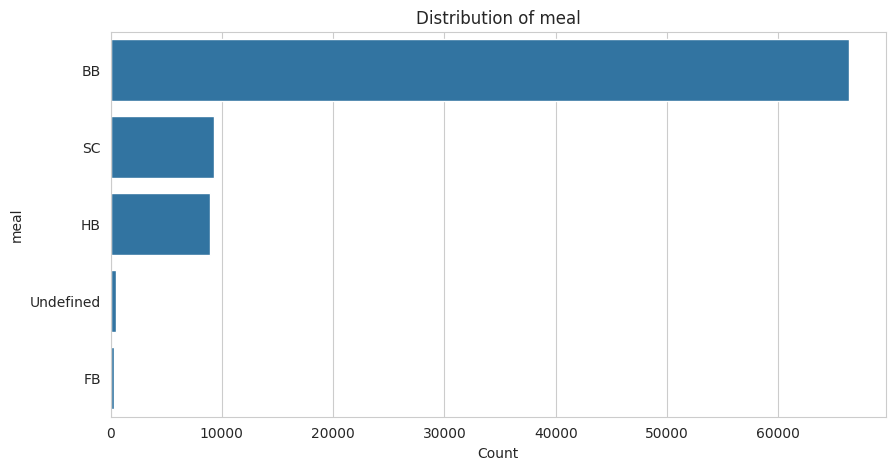


Unique Values : 5

Most Frequent Category :
BB
--------------------------------------------------------------------------------
Analysis of country
country
PRT    26177
GBR    10360
FRA     8786
ESP     7182
DEU     5366
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64


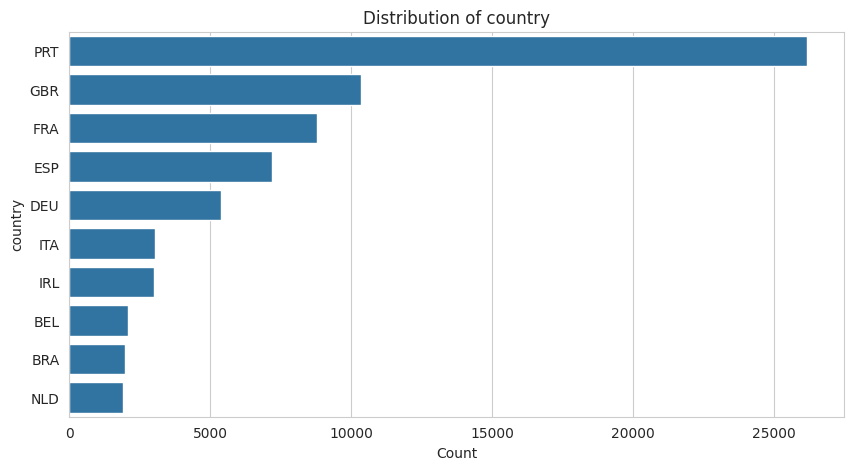


Unique Values : 177

Most Frequent Category :
PRT
--------------------------------------------------------------------------------
Analysis of market_segment
market_segment
Online TA        51185
Offline TA/TO    13622
Direct           11444
Groups            4733
Corporate         3961
Aviation           223
Complementary      142
Undefined            2
Name: count, dtype: int64


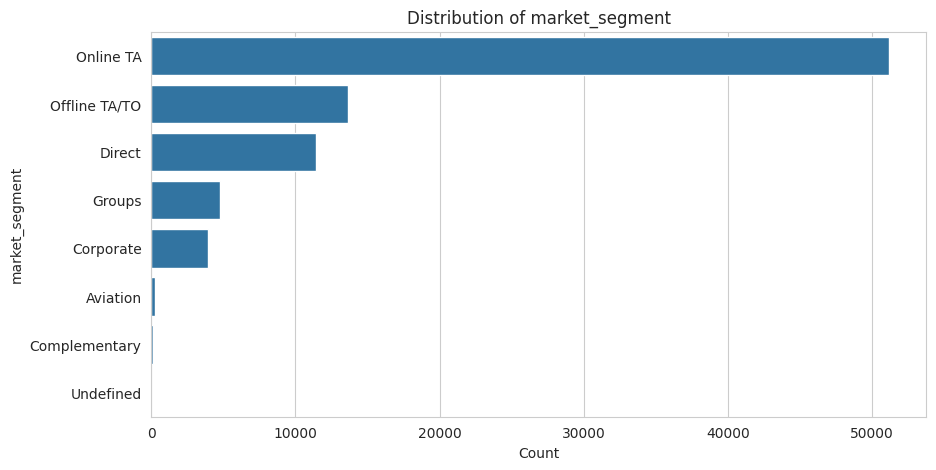


Unique Values : 8

Most Frequent Category :
Online TA
--------------------------------------------------------------------------------
Analysis of distribution_channel
distribution_channel
TA/TO        68228
Direct       12155
Corporate     4747
GDS            177
Undefined        5
Name: count, dtype: int64


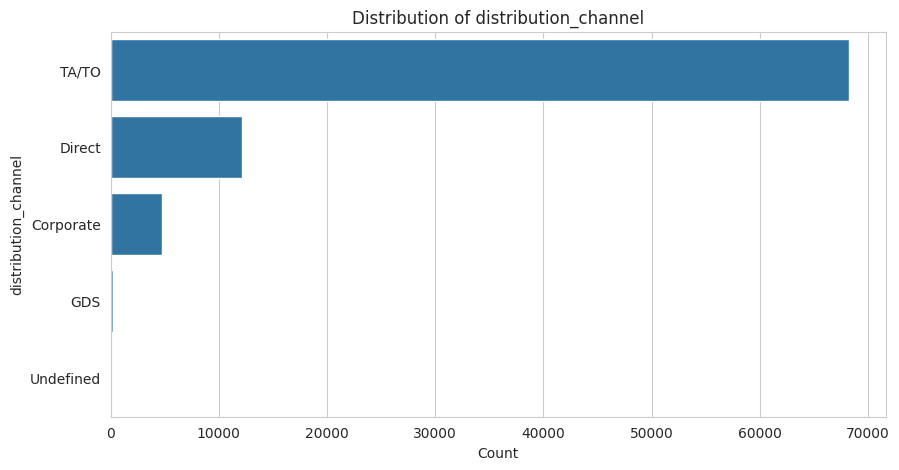


Unique Values : 5

Most Frequent Category :
TA/TO
--------------------------------------------------------------------------------
Analysis of reserved_room_type
reserved_room_type
A    55038
D    17188
E     5908
F     2751
G     1964
B      969
C      898
H      590
L        6
Name: count, dtype: int64


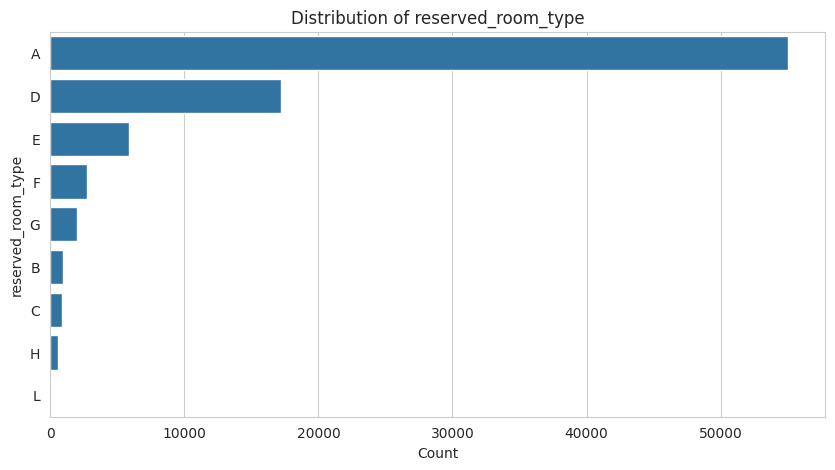


Unique Values : 9

Most Frequent Category :
A
--------------------------------------------------------------------------------
Analysis of assigned_room_type
assigned_room_type
A    45536
D    22001
E     7028
F     3520
G     2396
C     2101
B     1759
H      690
I      158
K      122
L        1
Name: count, dtype: int64


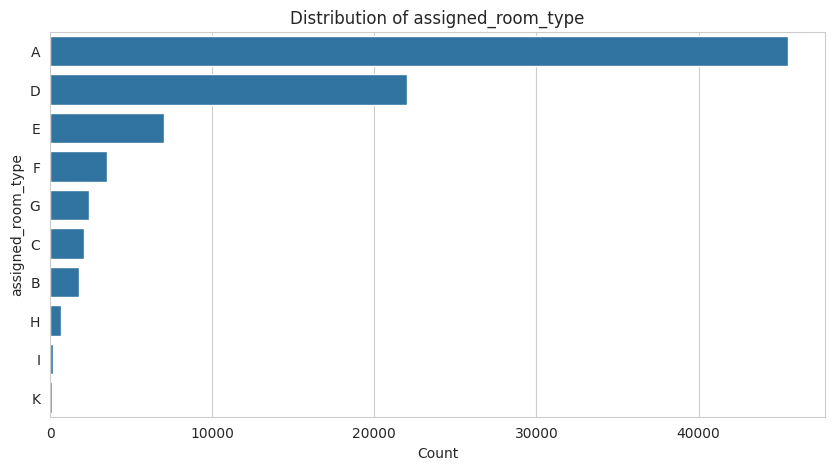


Unique Values : 11

Most Frequent Category :
A
--------------------------------------------------------------------------------
Analysis of deposit_type
deposit_type
No Deposit    84168
Non Refund     1037
Refundable      107
Name: count, dtype: int64


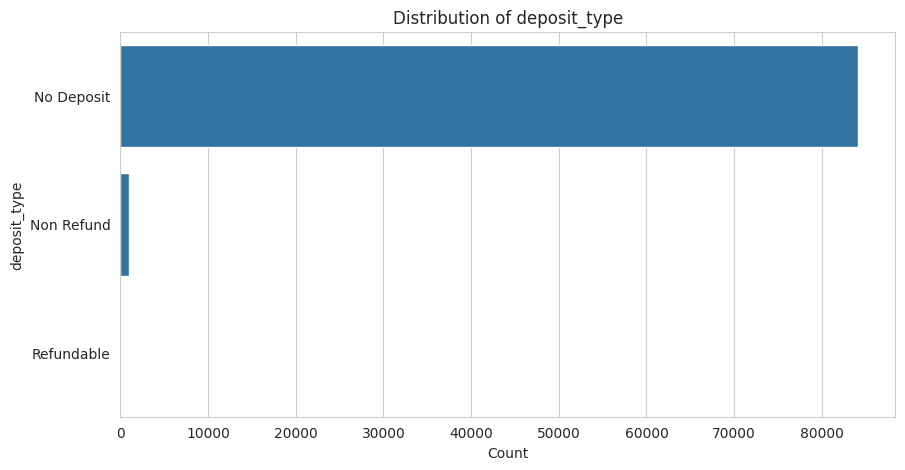


Unique Values : 3

Most Frequent Category :
No Deposit
--------------------------------------------------------------------------------
Analysis of customer_type
customer_type
Transient          70331
Transient-Party    11344
Contract            3116
Group                521
Name: count, dtype: int64


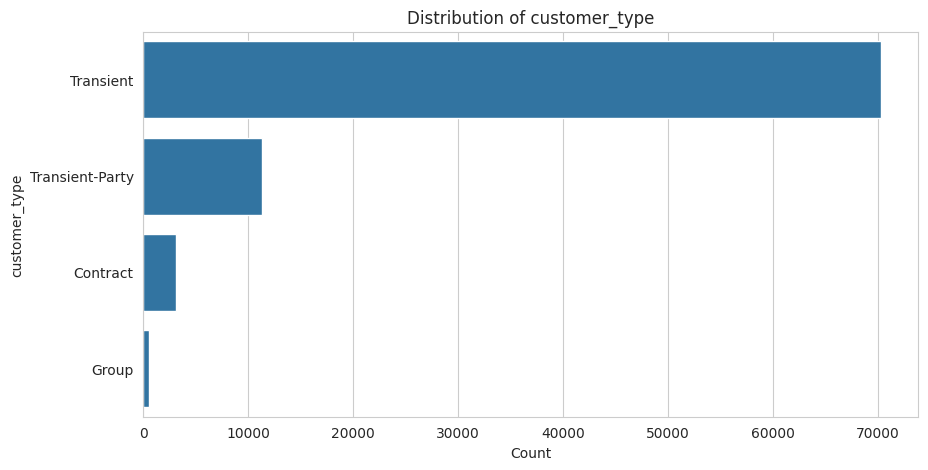


Unique Values : 4

Most Frequent Category :
Transient
--------------------------------------------------------------------------------
Analysis of reservation_status
reservation_status
Check-Out    61332
Canceled     22971
No-Show       1009
Name: count, dtype: int64


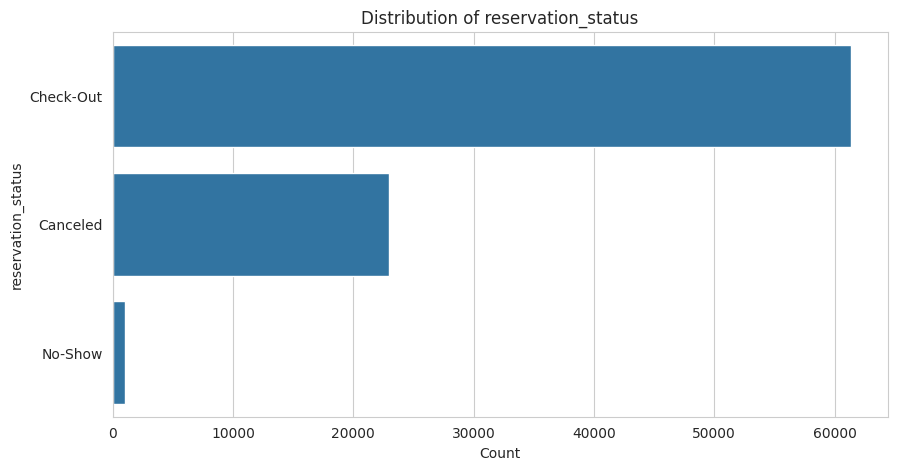


Unique Values : 3

Most Frequent Category :
Check-Out
--------------------------------------------------------------------------------
Analysis of reservation_status_date
reservation_status_date
2016-02-14    207
2017-05-25    198
2015-10-21    194
2016-03-28    194
2016-10-06    192
             ... 
2015-03-29      1
2015-04-27      1
2015-01-20      1
2015-02-17      1
2015-03-10      1
Name: count, Length: 926, dtype: int64


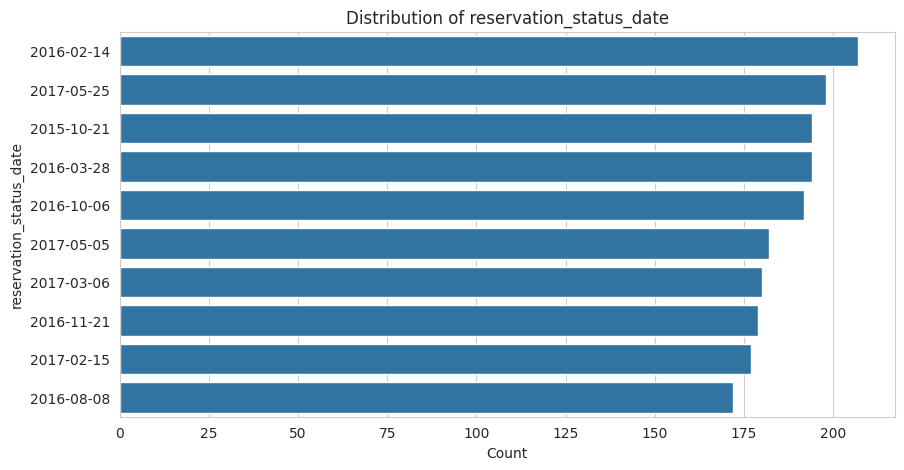


Unique Values : 926

Most Frequent Category :
2016-02-14
--------------------------------------------------------------------------------
Analysis of datetime
datetime
2017-04-29    236
2017-07-15    216
2016-06-26    210
2017-05-25    208
2017-04-13    203
             ... 
2015-11-15     26
2015-12-07     24
2015-12-15     23
2015-11-29     18
2015-12-13     18
Name: count, Length: 793, dtype: int64


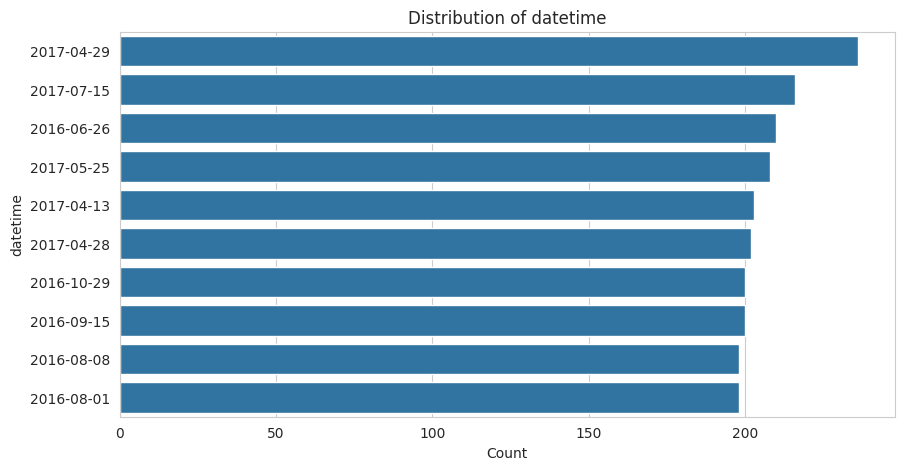


Unique Values : 793

Most Frequent Category :
2017-04-29 00:00:00
--------------------------------------------------------------------------------


In [40]:
#Univariate Analysis on Categorical Columns
for i in categorical_cols:

    print("="*60)
    print(f"Analysis of {i}")
    print("="*60)

    print(df[i].value_counts())

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=i,
        data=df,
        order=df[i].value_counts().head(10).index
    )

    plt.title(f"Distribution of {i}")
    plt.xlabel("Count")
    plt.ylabel(i)

    plt.show()

    print("\nUnique Values :", df[i].nunique())

    print("\nMost Frequent Category :")

    print(df[i].mode()[0])

    print("-"*80)

**Key Insights for Categorical Columns**

1. Hotel Type

The dataset contains a larger proportion of City Hotel bookings compared to Resort Hotel bookings, indicating that urban hotels experience higher booking demand. This may reflect greater demand from business travelers, short-term visitors, and city tourism.

2. Arrival Month

Booking demand peaks during August, followed by July and May, indicating that the summer season is the busiest period for hotel reservations. In contrast, January and November record the fewest bookings, suggesting lower travel demand during these months.

Business Insight:
Hotels should optimize pricing, staffing, and room availability during peak travel seasons while offering promotional discounts during off-peak months to improve occupancy.

3. Meal Plans

The Bed & Breakfast (BB) meal package is by far the most popular option among guests, while Full Board (FB) and Undefined meal plans are selected only by a small proportion of customers.

Business Insight:
Hotels should prioritize breakfast services and optimize inventory around the BB package, as it represents the primary customer preference.

4. Customer Country

The majority of guests originate from Portugal (PRT), followed by the United Kingdom (GBR), France (FRA), Spain (ESP), and Germany (DEU). Customers from many other countries contribute only a small number of bookings.

Business Insight:
Marketing campaigns and customer loyalty programs can be tailored toward the hotel's primary international markets while exploring opportunities to expand into underrepresented regions.

5. Market Segment

Most bookings are made through Online Travel Agencies (Online TA), followed by Offline Travel Agencies/Tour Operators and Direct bookings. Corporate, aviation, and complementary bookings account for a much smaller share.

Business Insight:
Online travel agencies play a critical role in customer acquisition. Hotels should strengthen relationships with major online booking platforms while also encouraging direct bookings to reduce commission costs.

6. Distribution Channel

The Travel Agent/Tour Operator (TA/TO) channel dominates hotel reservations, whereas Direct and Corporate channels contribute considerably fewer bookings.

Business Insight:
Hotels should evaluate the profitability of OTA partnerships while investing in strategies that increase direct bookings through official websites and loyalty programs.

7. Reserved Room Type

Most guests reserve Room Type A, with Room Types D and E following at a significant distance. Other room categories account for relatively few bookings.

Business Insight:
Hotels should ensure adequate availability and maintenance of the most frequently reserved room categories to maximize customer satisfaction and occupancy.

8. Assigned Room Type

Although Room Type A remains the most commonly assigned room, there are noticeable differences between reserved and assigned room types, indicating that room upgrades or substitutions occur for some guests.

Business Insight:
Analyzing differences between reserved and assigned rooms can help evaluate operational efficiency, upgrade policies, and customer satisfaction.

9. Deposit Type

The overwhelming majority of bookings require No Deposit, while Non-Refundable and Refundable deposits are relatively uncommon.

Business Insight:
Hotels rely primarily on flexible booking policies, which may increase booking volumes but could also contribute to higher cancellation rates.

10. Customer Type

Transient customers represent the largest customer segment by a substantial margin, followed by Transient-Party bookings. Contract and Group customers constitute only a small proportion of reservations.

Business Insight:
The hotel's revenue largely depends on individual travelers, making customer satisfaction, pricing strategies, and personalized marketing particularly important.

11. Reservation Status

Most reservations conclude with successful check-outs, while canceled bookings represent a significant proportion of the dataset. No-Show cases are relatively rare.

Business Insight:
Although the majority of bookings are completed successfully, reducing cancellations remains a key opportunity for improving occupancy and maximizing revenue.

12. Reservation Status Date

Reservation status updates are distributed across 926 unique dates, indicating consistent booking activity throughout the observation period rather than being concentrated within a few specific dates.

13. Booking Timeline (Datetime)

The combined arrival datetime feature shows bookings spread across 793 unique dates, with several peak booking days but no excessive dependence on a single date. This supports meaningful time-series analysis of booking demand and seasonal trends.

**Summary:**
The categorical analysis reveals that City Hotels receive the majority of bookings, with demand peaking during the summer months of July and August. Most customers book Bed & Breakfast packages, originate from Portugal and other major European countries, and make reservations through Online Travel Agencies or Travel Agent/Tour Operators. The customer base is dominated by Transient travelers, while No Deposit booking policies are the norm. Most reservations end in successful check-outs, although cancellations remain a substantial operational challenge. Overall, the dataset reflects a hotel business that relies heavily on leisure and individual travelers, with strong seasonal demand and significant dependence on third-party booking channels.

**Bivariate Leakage Drivers (Cancellation Profiling)**

In [41]:
#Deposit Policy Efficacy

# Evaluate how different deposit policies influence hotel booking cancellation rates.

deposit_cancel = (
    df.groupby("deposit_type")["is_canceled"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

deposit_cancel.columns = [
    "Deposit Type",
    "Total Bookings",
    "Canceled Bookings",
    "Cancellation Rate"
]

deposit_cancel["Cancellation Rate"] *= 100

deposit_cancel

,Deposit Type,Total Bookings,Canceled Bookings,Cancellation Rate
0,No Deposit,84168,22972,27.293033
1,Non Refund,1037,982,94.696239
2,Refundable,107,26,24.299065


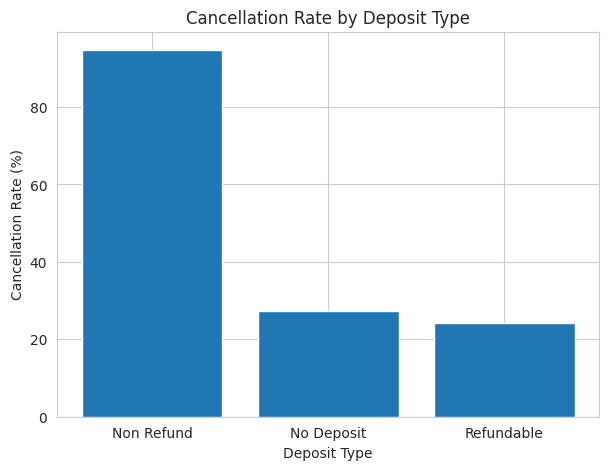

In [42]:
import matplotlib.pyplot as plt

deposit_cancel = deposit_cancel.sort_values("Cancellation Rate", ascending=False)

plt.figure(figsize=(7,5))
plt.bar(
    deposit_cancel["Deposit Type"],
    deposit_cancel["Cancellation Rate"]
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

**Key Insights**
1. Non-Refund bookings have the highest cancellation rate (~95%)
- Surprisingly, Non-Refund bookings exhibit the highest cancellation rate, at approximately 95%.
- This is counterintuitive because non-refundable bookings are generally expected to discourage cancellations.
- This pattern may indicate data quality issues, special business rules, or that "cancellation" in the dataset includes bookings that were canceled before payment was finalized.

2. No Deposit bookings have a moderate cancellation rate (~27%)
- Bookings without any deposit show a cancellation rate of around 27%.
- Since customers have no financial commitment, they are relatively more likely to cancel compared to refundable bookings.

3. Refundable bookings have the lowest cancellation rate (~24%)
- Refundable bookings have the lowest cancellation rate among the three deposit types.
- Although the difference between Refundable and No Deposit is small, refundable bookings appear to have slightly better customer commitment.

**Business Recommendation:** 
- Investigate why Non-Refund bookings have such an unusually high cancellation rate, as this differs from typical business expectations.
- Review booking and payment workflows to ensure the deposit_type field is correctly recorded.

In [43]:
#Lead Time Risk Cut-off

#Determine how the number of days between booking and arrival (lead_time) influences cancellation risk.

lead_cancel = (
    df.groupby("lead_time")["is_canceled"]
      .mean()
      .reset_index()
      .rename(columns={"is_canceled": "Cancellation Rate"})
)

lead_cancel["Cancellation Rate"] *= 100

print(lead_cancel["Cancellation Rate"])

lead_cancel.head()

0        6.366344
1        6.973640
2        9.879254
3       10.387216
4       10.086840
          ...    
473    100.000000
474    100.000000
475    100.000000
476    100.000000
477      0.000000
Name: Cancellation Rate, Length: 478, dtype: float64


,lead_time,Cancellation Rate
0,0,6.366344
1,1,6.973640
2,2,9.879254
3,3,10.387216
4,4,10.086840


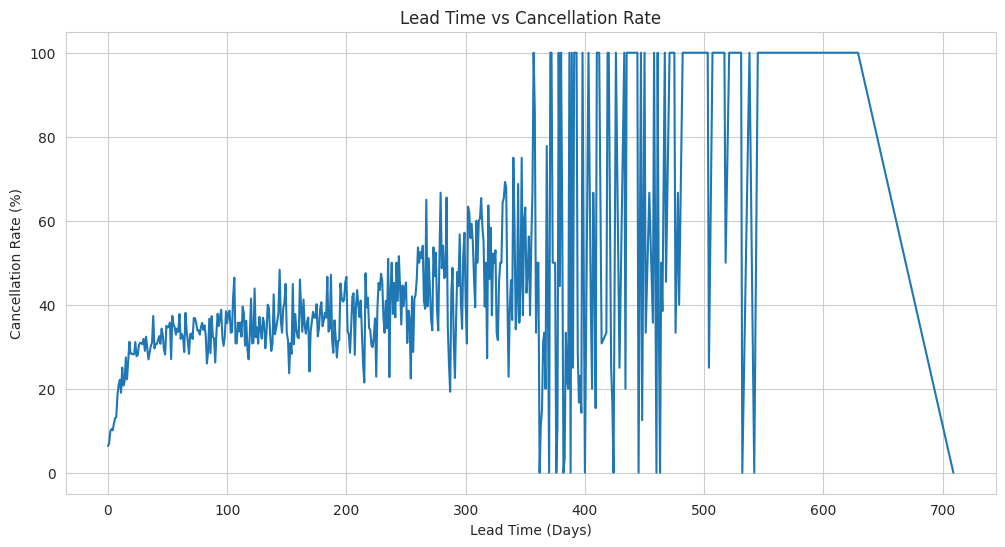

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    lead_cancel["lead_time"],
    lead_cancel["Cancellation Rate"]
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.title("Lead Time vs Cancellation Rate")

plt.grid(True)

plt.show()

In [45]:
bins = [0,30,60,90,180,365,800]

labels = [
    "0-30",
    "31-60",
    "61-90",
    "91-180",
    "181-365",
    "366+"
]

df["Lead_Time_Group"] = pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels
)

risk = (
    df.groupby("Lead_Time_Group")["is_canceled"]
      .mean()*100
)

risk

Lead_Time_Group
0-30       19.200347
31-60      31.965475
61-90      32.852685
91-180     35.227524
181-365    39.996395
366+       41.970803
Name: is_canceled, dtype: float64

**Key Insights**
- Longer lead times are associated with higher cancellation rates.
- Last-minute bookings(0-30) are the most reliable
- Bookings made more than one year in advance are the riskiest

**Business Recommendation:**

- Focus cancellation prevention efforts on customers who book more than 90 days in advance.
- Send reminder emails or confirmation requests closer to the arrival date for long lead-time bookings.
- Consider flexible pricing or promotional incentives to encourage customers to keep their reservations.

In [46]:
#Customer Segment Volatility

customer_cancel = pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
)*100

customer_cancel

is_canceled,0,1
customer_type,,
Contract,83.568678,16.431322
Group,89.827255,10.172745
Transient,69.239738,30.760262
Transient-Party,84.300071,15.699929


In [47]:
customer_cancel.columns = [
    "Not Canceled",
    "Canceled"
]

customer_cancel

,Not Canceled,Canceled
customer_type,,
Contract,83.568678,16.431322
Group,89.827255,10.172745
Transient,69.239738,30.760262
Transient-Party,84.300071,15.699929


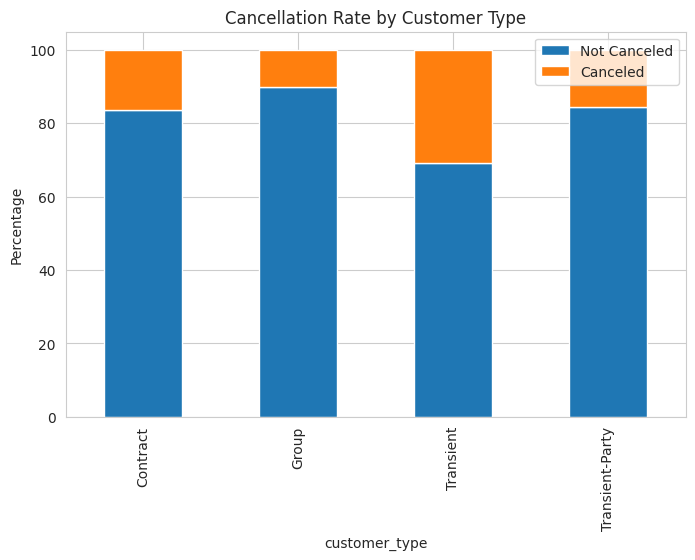

In [48]:
customer_cancel.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Cancellation Rate by Customer Type")

plt.ylabel("Percentage")

plt.legend(loc="upper right")

plt.show()

**Key Insights**

- Transient customer type have the highest cancellation.
- Group bookings have the lowest cancellation rate among the 4.
- The customer segment with the highest percentage of canceled bookings represents the greatest operational risk.
- If transient customers dominate both booking volume and cancellations, improving engagement with this segment could have the largest impact on reducing overall cancellations.

In [49]:
#Multivariate Analysis

#Distribution Channel Margin Grid

#Objective

#Compare each distribution channel based on:

#Average Daily Rate (adr)
#Cancellation Rate (is_canceled)
#Total Bookings

channel_analysis = (
    df.groupby("distribution_channel")
      .agg(
          Total_Bookings=("distribution_channel", "count"),
          Average_ADR=("adr", "mean"),
          Cancellation_Rate=("is_canceled", "mean")
      )
      .reset_index()
)

channel_analysis["Cancellation_Rate"] *= 100

channel_analysis

,distribution_channel,Total_Bookings,Average_ADR,Cancellation_Rate
0,Corporate,4747,71.664415,13.355804
1,Direct,12155,115.571076,15.713698
2,GDS,177,123.036893,20.338983
3,TA/TO,68228,109.871387,31.359559
4,Undefined,5,46.240000,80.000000


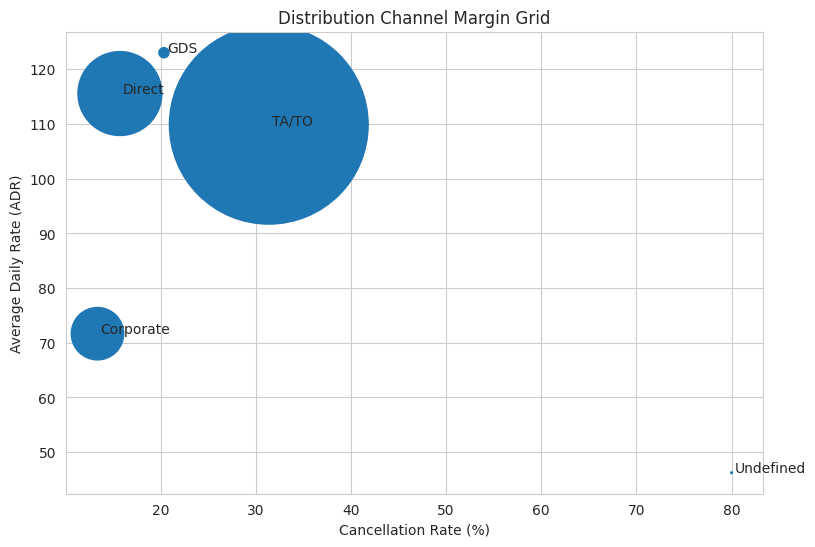

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    channel_analysis["Cancellation_Rate"],
    channel_analysis["Average_ADR"],
    s=channel_analysis["Total_Bookings"]*0.3
)

for i,row in channel_analysis.iterrows():
    plt.text(
        row["Cancellation_Rate"]+0.3,
        row["Average_ADR"],
        row["distribution_channel"]
    )

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Average Daily Rate (ADR)")
plt.title("Distribution Channel Margin Grid")

plt.grid(True)

plt.show()

**Key Insights**

- Direct bookings often exhibit lower cancellation rates because customers interact directly with the hotel, reducing intermediary uncertainty.
- TA/TO (Travel Agent/Tour Operator) channels typically contribute the largest booking volume. Compare whether their higher ADR compensates for any elevated cancellation rate.
- Corporate bookings often show stable demand and lower volatility, making them valuable even if their ADR is not the highest.
- If a channel has both high ADR and low cancellation rates, it is generally the most profitable.

In [51]:
#Room Allocation Discrepancy Audits

room_changed = df[
    df["reserved_room_type"] != df["assigned_room_type"]
]

room_changed.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,datetime,Lead_Time_Group
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02,1.0,2015-07-01,0-30
11,Resort Hotel,0,68,2015,July,27,1,0,4,2,0.0,0,BB,USA,Online TA,TA/TO,0,0,0,D,E,0,No Deposit,240.0,0,Transient,97.00,0,3,Check-Out,2015-07-05,2.0,2015-07-01,61-90
14,Resort Hotel,0,68,2015,July,27,1,0,4,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,D,E,0,No Deposit,240.0,0,Transient,97.00,0,3,Check-Out,2015-07-05,2.0,2015-07-01,61-90
16,Resort Hotel,0,12,2015,July,27,1,0,1,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,A,E,0,No Deposit,240.0,0,Transient,88.20,0,0,Check-Out,2015-07-02,2.0,2015-07-01,0-30
17,Resort Hotel,0,0,2015,July,27,1,0,1,2,0.0,0,BB,FRA,Corporate,Corporate,0,0,0,A,G,0,No Deposit,0.0,0,Transient,107.42,0,0,Check-Out,2015-07-02,2.0,2015-07-01,NaN


In [52]:
print("Room Changes:", len(room_changed))

print(
    "Percentage:",
    round(
        len(room_changed)/len(df)*100,
        2
    ),
    "%"
)

Room Changes: 12127
Percentage: 14.21 %


In [53]:
room_cancel = (
    df.assign(
        Room_Changed=df["reserved_room_type"] != df["assigned_room_type"]
    )
    .groupby("Room_Changed")["is_canceled"]
    .mean()*100
)

room_cancel

Room_Changed
False    31.935506
True      5.013606
Name: is_canceled, dtype: float64

In [54]:
repeat_rate = (
    df.assign(
        Room_Changed=df["reserved_room_type"] != df["assigned_room_type"]
    )
    .groupby("Room_Changed")["is_repeated_guest"]
    .mean()*100
)

repeat_rate

Room_Changed
False    2.924096
True     6.572112
Name: is_repeated_guest, dtype: float64

In [55]:
room_summary = (
    df.assign(
        Room_Changed=df["reserved_room_type"] != df["assigned_room_type"]
    )
    .groupby("Room_Changed")
    .agg(
        Total_Bookings=("hotel","count"),
        Cancellation_Rate=("is_canceled","mean"),
        Repeat_Guest_Rate=("is_repeated_guest","mean"),
        Average_ADR=("adr","mean")
    )
    .reset_index()
)

room_summary["Cancellation_Rate"]*=100
room_summary["Repeat_Guest_Rate"]*=100

room_summary

,Room_Changed,Total_Bookings,Cancellation_Rate,Repeat_Guest_Rate,Average_ADR
0,False,73185,31.935506,2.924096,111.673013
1,True,12127,5.013606,6.572112,89.921801


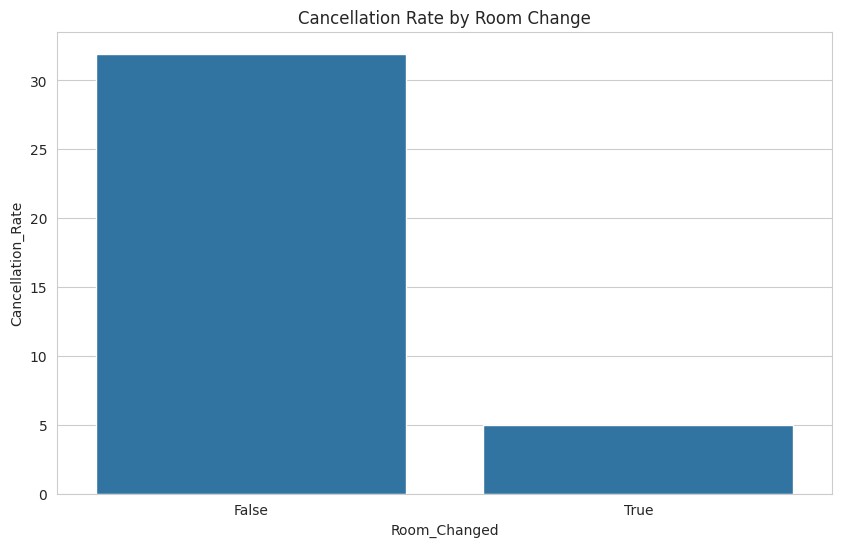

In [56]:
import seaborn as sns

sns.barplot(
    data=room_summary,
    x="Room_Changed",
    y="Cancellation_Rate"
)

plt.title("Cancellation Rate by Room Change")

plt.show()

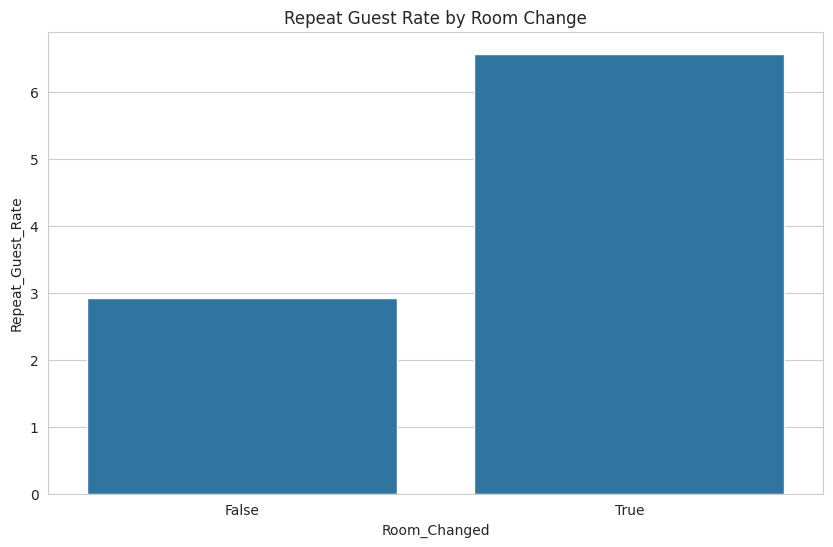

In [57]:
sns.barplot(
    data=room_summary,
    x="Room_Changed",
    y="Repeat_Guest_Rate"
)

plt.title("Repeat Guest Rate by Room Change")

plt.show()

**Key Insights**

- 1. Bookings with no room change have a much higher cancellation rate.
  2. Customers whose rooms were changed rarely canceled.
  3. Room changes are unlikely to be the cause of cancellations.

**Business Insight**
The low cancellation rate among bookings with room changes indicates that room reassignments do not negatively impact customer commitment. Instead, most cancellations occur before room allocation, suggesting that hotels should focus on reducing early-stage cancellations rather than concerns about room reassignment.

**The Financial Exposure Model**

In [58]:
#The Lost Revenue Metric

# Calculate total stay nights
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

# Calculate lost revenue only for cancelled bookings
df["Lost_Revenue"] = 0

df.loc[df["is_canceled"] == 1, "Lost_Revenue"] = (
    df["adr"] * df["total_nights"]
)

In [59]:
df[["is_canceled","adr","total_nights","Lost_Revenue"]].head(10)

,is_canceled,adr,total_nights,Lost_Revenue
2,0,75.0,1,0.0
3,0,75.0,1,0.0
4,0,98.0,2,0.0
5,0,107.0,2,0.0
6,0,103.0,2,0.0
7,1,82.0,3,246.0
8,1,105.5,3,316.5
9,1,123.0,4,492.0
10,0,145.0,4,0.0
11,0,97.0,4,0.0


**Key Insights**

- Lost revenue is incurred only when a booking is canceled. All non-canceled bookings have a Lost_Revenue value of 0, while canceled bookings contribute directly to revenue loss.
- Lost revenue increases with both the Average Daily Rate (ADR) and the total number of nights booked. High-value reservations with longer stays result in significantly greater financial losses when canceled.
- Long-duration bookings represent a higher financial risk. Even a small number of cancellations involving multi-night stays can have a substantial impact on hotel revenue.
- Bookings with higher ADR values generate higher revenue losses upon cancellation. Premium rooms and peak-season reservations are therefore more critical to monitor.
- The Lost_Revenue metric helps quantify the direct financial impact of cancellations, enabling hotel management to move beyond simply counting cancellations and instead measure their monetary effect.
- Not all cancellations have the same business impact. A cancellation of a one-night, low-priced booking has far less financial consequence than a cancellation of a long-stay, high-priced reservation.
- This metric enables prioritization of high-value bookings. Management can identify reservations that contribute the most to lost revenue and develop targeted strategies to reduce cancellations for these bookings.

In [60]:
#Programmatic Aggregation

def calculate_total_lost_revenue(df):
    """
    Calculates total revenue lost due to cancelled bookings.
    """

    total = (
        df.loc[df["is_canceled"] == 1, "Lost_Revenue"]
        .sum()
    )

    return total

In [61]:
total_loss = calculate_total_lost_revenue(df)

print(f"Total Revenue Lost: ${total_loss:,.2f}")

Total Revenue Lost: $11,476,302.52


Total revenue Loss due to cancellation and other factors are : $11,476,302.52

In [62]:
#Strategic Business Unit Breakdown

hotel_loss = (
    df[df["is_canceled"] == 1]
    .groupby("hotel")
    .agg(
        Cancelled_Bookings=("hotel","count"),
        Revenue_Lost=("Lost_Revenue","sum"),
        Average_Loss=("Lost_Revenue","mean")
    )
    .sort_values(
        by="Revenue_Lost",
        ascending=False
    )
)

hotel_loss

,Cancelled_Bookings,Revenue_Lost,Average_Loss
hotel,,,
City Hotel,16034,6614260.63,412.514696
Resort Hotel,7946,4862041.89,611.885463


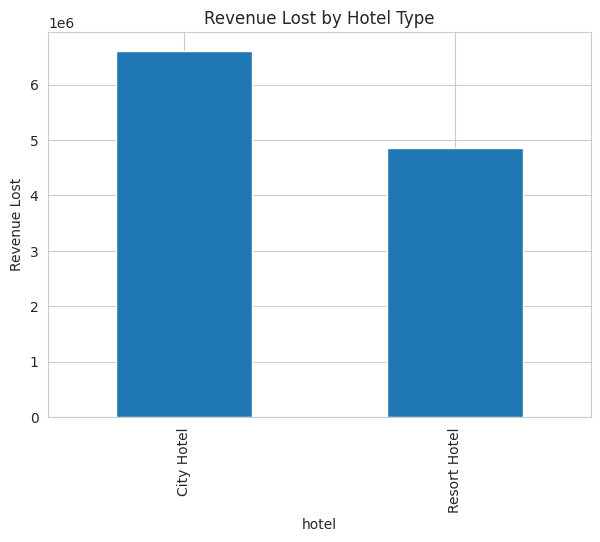

In [63]:
import matplotlib.pyplot as plt

hotel_loss["Revenue_Lost"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Revenue Lost by Hotel Type")
plt.ylabel("Revenue Lost")

plt.show()

**Key Insights**

- City Hotels account for the highest revenue loss due to booking cancellations, with an estimated loss of approximately ₹6.61 million, compared to ₹4.86 million for Resort Hotels.
- City Hotels recorded over twice the number of cancelled bookings (16,034) compared to Resort Hotels (7,946), making them the primary contributor to revenue leakage.
- Although Resort Hotels experience fewer cancellations, the average revenue lost per cancelled booking (≈ ₹612) is significantly higher than that of City Hotels (≈ ₹413).
- The higher average loss in Resort Hotels indicates that guests typically book longer stays, higher room categories, or higher ADR (Average Daily Rate) properties.
- From a business perspective, City Hotels should focus on reducing cancellation volume, while Resort Hotels should prioritize protecting high-value reservations.

In [64]:
segment_loss = (
    df[df["is_canceled"] == 1]
    .groupby("market_segment")
    .agg(
        Cancelled_Bookings=("market_segment","count"),
        Revenue_Lost=("Lost_Revenue","sum"),
        Average_Loss=("Lost_Revenue","mean")
    )
    .sort_values(
        by="Revenue_Lost",
        ascending=False
    )
)

segment_loss

,Cancelled_Bookings,Revenue_Lost,Average_Loss
market_segment,,,
Online TA,18242,9292901.94,509.423415
Direct,1724,924467.07,536.233799
Offline TA/TO,2053,819748.52,399.292996
Groups,1332,315619.75,236.951764
Corporate,497,109182.25,219.682596
Aviation,45,14065.00,312.555556
Complementary,85,269.99,3.176353
Undefined,2,48.00,24.000000


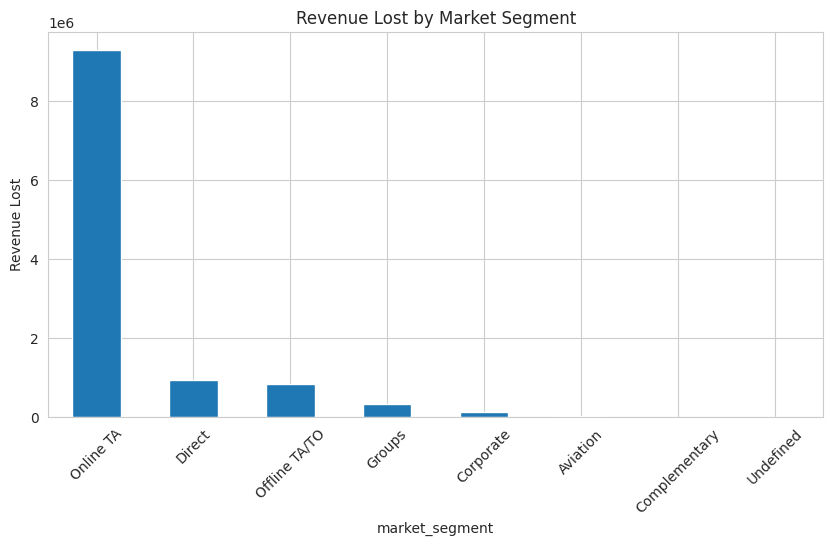

In [65]:
segment_loss["Revenue_Lost"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue Lost by Market Segment")

plt.ylabel("Revenue Lost")

plt.xticks(rotation=45)

plt.show()

**Key Insights**

1. Online Travel Agencies (Online TA) contribute by far the highest revenue loss, accounting for approximately ₹9.43 million, making them the largest source of cancellation-related revenue leakage.
2. Direct bookings and Offline Travel Agencies (Offline TA/TO) are the second and third largest contributors to lost revenue, although they are substantially lower than Online TA.
3. Group bookings contribute moderate revenue loss, indicating that cancellations from organized travel groups still represent a noticeable financial impact.
4. Corporate, Aviation, Complimentary, and Undefined market segments contribute very little to total revenue loss, indicating comparatively stable booking behavior.
5. The extremely high revenue loss from Online TA is driven by both the highest cancellation volume and the largest booking share.

In [66]:
#Combined Business Unit Analysis

business_unit = (
    df[df["is_canceled"] == 1]
    .groupby(["hotel","market_segment"])
    .agg(
        Cancelled_Bookings=("hotel","count"),
        Revenue_Lost=("Lost_Revenue","sum"),
        Average_ADR=("adr","mean")
    )
    .reset_index()
)

business_unit.sort_values(
    by="Revenue_Lost",
    ascending=False
)

,hotel,market_segment,Cancelled_Bookings,Revenue_Lost,Average_ADR
6,City Hotel,Online TA,12615,5587420.99,122.637824
13,Resort Hotel,Online TA,5627,3705480.95,129.072667
10,Resort Hotel,Direct,812,504211.63,130.738830
12,Resort Hotel,Offline TA/TO,797,464694.85,86.501518
3,City Hotel,Direct,912,420255.44,123.343936
5,City Hotel,Offline TA/TO,1256,355053.67,95.508790
4,City Hotel,Groups,887,184311.32,83.694104
11,Resort Hotel,Groups,445,131308.43,61.675416
9,Resort Hotel,Corporate,234,56271.03,68.678162
2,City Hotel,Corporate,263,52911.22,90.012586


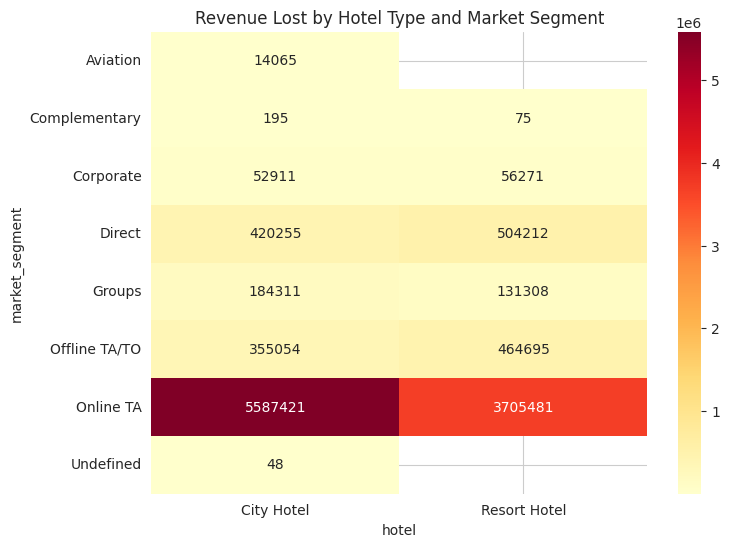

In [67]:

pivot = business_unit.pivot(
    index="market_segment",
    columns="hotel",
    values="Revenue_Lost"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Revenue Lost by Hotel Type and Market Segment")

plt.show()

**Key Insights**

- City Hotel bookings made through Online Travel Agencies generate the highest revenue loss across all business combinations, exceeding ₹5.8 million.
- Resort Hotel bookings from Online Travel Agencies represent the second-largest source of revenue loss, contributing approximately ₹3.7 million.
- Direct bookings are the second most significant contributor to lost revenue in both hotel types, particularly within City Hotels.
- Offline Travel Agencies (Offline TA/TO) also generate substantial cancellation losses for both City and Resort Hotels, although considerably less than Online TA.
- Corporate and Group bookings contribute moderate revenue losses, while Aviation, Complimentary, and Undefined segments have minimal financial impact.
- The heatmap clearly shows that Online TA dominates revenue loss regardless of hotel type, indicating that booking channel is a stronger driver of revenue leakage than hotel type alone.
- City Hotels consistently experience higher cancellation losses across nearly every market segment, suggesting a greater operational and financial exposure.

# Summary

This project analyzed over 119,000 hotel booking records to identify the primary factors influencing booking cancellations, customer behavior, operational efficiency, and revenue loss. The analysis combined descriptive statistics, exploratory data analysis (EDA), univariate, bivariate, multivariate, and financial impact assessments to uncover actionable business insights.

The findings reveal that approximately 28% of all bookings were canceled, representing a significant operational and financial challenge. Booking demand is concentrated in City Hotels, particularly during the summer months, with most reservations coming through Online Travel Agencies (OTA) and Travel Agent/Tour Operator (TA/TO) channels. The majority of customers are first-time transient travelers booking short stays for one or two adults, while repeat customers account for only a small proportion of reservations.

Financial analysis demonstrates that booking cancellations result in substantial historical revenue leakage, with City Hotels and the Online TA market segment contributing the highest losses. Although premium bookings occur less frequently, their higher ADR means each cancellation has a much greater financial impact. The study also highlights that operational practices such as room reallocations, deposit policies, booking lead time, and distribution channels significantly influence cancellation behavior and customer loyalty.

Overall, the analysis provides a comprehensive understanding of customer booking patterns, operational risks, and revenue optimization opportunities that can support better strategic decision-making in hotel management.

# Conclusions

The hotel booking analysis indicates that customer cancellations are influenced by a combination of booking policies, customer segments, distribution channels, booking lead time, and pricing strategies rather than a single operational factor.

Hotels currently rely heavily on flexible No Deposit policies and third-party booking platforms, which contribute to higher cancellation rates and increased revenue leakage. While Online Travel Agencies generate the highest booking volumes, they also account for the largest share of financial losses due to cancellations. Conversely, Direct and Corporate booking channels demonstrate greater booking reliability and lower operational risk.

The customer base is largely composed of first-time transient guests, suggesting an opportunity to strengthen customer retention through personalized experiences and loyalty initiatives. Analysis of room allocation indicates that room upgrades do not necessarily reduce customer satisfaction and may even improve guest loyalty when managed effectively.

From a revenue management perspective, cancellations involving high-ADR bookings have a disproportionate financial impact despite representing fewer reservations. Therefore, protecting premium bookings should become a strategic priority. Seasonal demand patterns, dominated by summer travel, further emphasize the need for dynamic pricing and resource planning throughout the year.

Overall, the findings demonstrate that integrating customer behavior analytics with operational and financial metrics can substantially improve hotel profitability, occupancy management, and long-term customer retention.

# Advice

*1. Reduce Cancellation Risk Through Smarter Deposit Policies*

- Introduce non-refundable or partially refundable deposit options for high-risk booking channels and long lead-time reservations.
- Continue offering flexible cancellation policies selectively to maintain competitiveness while minimizing unnecessary revenue leakage.

*2. Increase Direct Bookings*

- Invest in hotel websites, mobile applications, and loyalty programs to encourage direct reservations.
- Offer exclusive discounts, complimentary services, or reward points for customers booking directly.
- Reducing dependence on Online Travel Agencies will decrease commission expenses and improve booking reliability.

*3. Improve Revenue Management*

- Monitor cancellations by hotel type, market segment, and distribution channel on a regular basis.
- Apply dynamic pricing strategies during high-demand seasons such as July and August.
- Protect premium ADR bookings using stricter cancellation policies and targeted customer engagement.

*4. Strengthen Customer Retention*

- Develop loyalty programs aimed at converting first-time guests into repeat customers.
- Personalize promotions based on customer booking history, country of origin, and travel preferences.
- Focus retention efforts on high-value customer segments that generate greater long-term revenue.

*5. Optimize Distribution Channels*
- Continuously evaluate the profitability of each distribution channel by considering:
    - Booking volume
    - Average Daily Rate (ADR)
    - Cancellation rate
    - Commission costs
- Increase marketing investments toward channels demonstrating high revenue with low cancellation risk.

*6. Enhance Operational Efficiency*

- Monitor discrepancies between reserved and assigned room types.
- Where possible, use room upgrades strategically to improve guest satisfaction and increase repeat visits.
- Analyze situations where room changes lead to dissatisfaction and implement operational improvements to minimize unnecessary reallocations.

*7. Improve Lead Time Management*

- Identify reservations with long booking lead times that historically exhibit higher cancellation rates.
- Send automated confirmation emails, payment reminders, and promotional offers before arrival to increase booking commitment.

*8. Leverage Seasonal Demand* 

- Increase staffing levels and room availability during peak travel months.
- Launch promotional campaigns and package offers during off-peak seasons to improve occupancy rates and stabilize revenue throughout the year.

*9. Focus on High-Value Market Segments*
- Closely monitor premium bookings with high ADR since cancellations from these customers create the greatest financial losses.
- Provide personalized services, flexible upgrade options, and targeted incentives to retain high-value guests.

This analysis demonstrates that hotel booking cancellations are not solely an operational issue but a significant revenue management challenge. By combining customer behavior analysis, booking channel performance, pricing strategies, and financial impact assessments, hotels can make more informed decisions that reduce revenue leakage, optimize occupancy, improve customer satisfaction, and maximize long-term profitability. The insights generated in this project provide a strong foundation for implementing data-driven revenue management and customer retention strategies in the hospitality industry.